# Business Case 1 - Segmenting Clients

This version is split into smaller notebook cells so the workflow is easier to follow.

**Notebook flow**
1. Setup and configuration  
2. Function definitions by topic  
3. Data loading and cleaning  
4. Model benchmarking and `k` choice  
5. Final segmentation  
6. Robustness checks  
7. Profile tables and exports  
8. Graphs, each in its own cell  
9. Summary


## 1) Imports

In [1]:
from __future__ import annotations

import math
import os
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_samples,
    silhouette_score,
)

from sklearn.manifold import TSNE
from sklearn.manifold import MDS
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from IPython.display import Image, display


In [2]:
from sklearn_extra.cluster import KMedoids

## 2) Configuration

In [3]:
# Path to the dataset
data_path = r"C:\Users\Maxime\Documents\Milan\Fintech\BusinessCase1\Dataset1_BankClients.xlsx"
metadata_path = r"C:\Users\Maxime\Documents\Milan\Fintech\BusinessCase1\BankClients_Metadata.xlsx"

# Directory where all outputs (models, plots, results) will be saved
OUTPUT_DIR = r"C:\Users\Maxime\Documents\Milan\Fintech\BusinessCase1"
RANDOM_STATE = 42

# List of k values, number of clusters tested for the k-means algorithm
CANDIDATE_K = [4, 5, 6, 7, 8]
# Number of samples used for benchmarking (to reduce computation time)
BENCHMARK_SAMPLE_SIZE = 1200
# Number of samples used for silhouette score (to reduce computation time)
SILHOUETTE_SAMPLE_SIZE = 800

# Grid of values to test for DBSCAN (they correspond to the maximum radius of neighborhood)
DBSCAN_EPS_GRID = [0.14, 0.16, 0.18, 0.20, 0.22, 0.24, 0.26]
# Minimum number of points required to form a dense region in DBSCAN
DBSCAN_MIN_SAMPLES = 25

# List of categorical columns in the dataset
CATEGORICAL_COLS = ["Gender", "Job", "Area", "CitySize", "Investments"]

# Value mapping: introduces dictionaries to convert numeric codes into readable labels
VALUE_MAPS: Dict[str, Dict[int, str]] = {
    "Gender": {0: "Male", 1: "Female"},
    "Job": {
        1: "Unemployed",
        2: "Employee/Worker",
        3: "Manager/Executive",
        4: "Entrepreneur/Freelancer",
        5: "Retired",
    },
    "Area": {1: "North", 2: "Center", 3: "South/Islands"},
    "CitySize": {1: "Small town", 2: "Medium city", 3: "Large city"},
    "Investments": {
        1: "No investments",
        2: "Mostly lump sum",
        3: "Mostly capital accumulation",
    },
}

# Expected ranges for numerical variables
NUMERIC_BOUNDS = {
    "Age": (18, 100),
    "FamilySize": (1, 10),
    "Income": (0, 1),
    "Wealth": (0, 1),
    "Debt": (0, 1),
    "FinEdu": (0, 1),
    "ESG": (0, 1),
    "Digital": (0, 1),
    "BankFriend": (0, 1),
    "LifeStyle": (0, 1),
    "Luxury": (0, 1),
    "Saving": (0, 1),
}

#The number of features imposed by the PCA is necessary to reduce the computation time
# And to identify which features contribute the most to the overall variance in the dataset
GMM_PCA_N_COMPONENTS = 10


# Each feature will be assigned to a block (demographic, financial, behavioral)
# We will assign a weight to each of these blocks according to their importance

FEATURE_BLOCKS = {
    "Age": "demographic",
    "Gender": "demographic",
    "Job": "demographic",
    "Area": "demographic",
    "CitySize": "demographic",
    "FamilySize": "demographic",
    "Income": "financial",
    "Wealth": "financial",
    "Debt": "financial",
    "Saving": "financial",
    "FinEdu": "behavioral",
    "ESG": "behavioral",
    "Digital": "behavioral",
    "BankFriend": "behavioral",
    "LifeStyle": "behavioral",
    "Luxury": "behavioral",
    "Investments": "behavioral",
}

# Create output directory if it does not exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 3) Data structures

In [4]:
# Dataclass used to store the output of a K-Medoids clustering run
@dataclass
class KMedoidsResult:
    # Array containing the selected medoids
    medoids: np.ndarray

    # Cluster label assigned to each observation
    labels: np.ndarray

    # Total clustering cost (sum of distances to the assigned medoids)
    total_cost: float

    # Number of iterations performed before convergence
    n_iter: int


# Dataclass used to store the cleaned and prepared dataset
@dataclass
class PreparedData:
    # Final prepared dataset after preprocessing
    data: pd.DataFrame

    # Metadata associated with the dataset (feature descriptions, etc.)
    metadata: pd.DataFrame

    # List of numerical columns kept in the dataset
    numeric_cols: List[str]

    # List of categorical columns kept in the dataset
    categorical_cols: List[str]

    # Columns that have zero variance
    removed_zero_variance_cols: List[str]

    # Columns with very low variance
    near_zero_variance_cols: List[str]

    # Audit log describing the preprocessing steps that were applied
    audit_lines: List[str]

## 4) Cleaning functions

In [5]:
# Detect different forms of missing values and replaces them with np.nan
def normalize_missing_tokens(df: pd.DataFrame) -> pd.DataFrame:
    tokens = {"", " ", "NA", "N/A", "na", "n/a", "null", "None", "none", "-", "--"}
    out = df.copy()
    for col in out.columns:
        if out[col].dtype == object:
            out[col] = out[col].replace(list(tokens), np.nan)
    return out

# Detect whether a feature has near-zero variance
def detect_near_zero_variance(series: pd.Series) -> bool:
    s = series.dropna()

    # If the column is empty, it is considered useless and we return True 
    if s.empty:
        return True
        
    # If a column contains only one value, it is considered useless and we return True 
    counts = s.value_counts()
    if len(counts) == 1:
        return True

    # Compute the ratio between the most frequent and second most frequent values
    freq_ratio = counts.iloc[0] / max(counts.iloc[1], 1)
    
    # Compute the ratio between the number of different values and the total number of observations used to measure the diversity of values in this feature
    pct_unique = s.nunique() / len(s)
    return (freq_ratio >= 20) and (pct_unique <= 0.10)


def clean_and_audit_data(data: pd.DataFrame, metadata: pd.DataFrame) -> PreparedData:
    # Initialize an audit log to keep track of all cleaning steps
    audit_lines: List[str] = []

    # Create a working copy of the dataset and standardize missing-value tokens
    df = normalize_missing_tokens(data.copy())
    
    # Start audit report
    audit_lines.append("DATA AUDIT")
    audit_lines.append("=" * 80)
    audit_lines.append(f"Initial shape: {df.shape}")

    # Remove fully duplicated rows
    exact_dupes = int(df.duplicated().sum())
    if exact_dupes > 0:
        df = df.drop_duplicates().copy()
    audit_lines.append(f"Exact duplicate rows removed: {exact_dupes}")

    # Remove duplicated IDs, keeping only the first occurrence
    duplicate_ids = int(df["ID"].duplicated().sum())
    if duplicate_ids > 0:
        df = df.drop_duplicates(subset=["ID"], keep="first").copy()
    audit_lines.append(f"Duplicate IDs removed: {duplicate_ids}")
    
    # Delete the columns 'ID' that doesn't contains any usefull information for the clustering 
    df = df.drop(columns=['ID'])

    # Identify categorical columns
    # Identify numeric columns by excluding ID and categorical columns
    categorical_cols = CATEGORICAL_COLS.copy()
    numeric_cols = [c for c in df.columns if c not in categorical_cols]

    # Convert columns to numeric (for instance "2" to 2). Invalid values become NaN
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


    # Validate categorical codes against allowed values defined in VALUE_MAPS
    # All invalid values become: NaN
    audit_lines.append("Invalid categorical codes replaced with missing values:")
    for col in categorical_cols:
        allowed = set(VALUE_MAPS[col].keys())
        invalid_mask = ~df[col].isin(allowed) & df[col].notna()
        invalid_count = int(invalid_mask.sum())
        if invalid_count > 0:
            df.loc[invalid_mask, col] = np.nan
        audit_lines.append(f"  - {col}: {invalid_count}")

    # Limit numeric variables to the valid bounds defined in NUMERIC_BOUNDS
    # If a value is greater than the maximum allowed value, it takes the higher value
    # Conversely, if a value is less than the minimum allowed value, it takes the lower value
    audit_lines.append("Out-of-range numeric values clipped to allowed bounds:")
    for col, (lower, upper) in NUMERIC_BOUNDS.items():
        if col not in df.columns:
            continue
        before = df[col].copy()
        df[col] = df[col].clip(lower=lower, upper=upper)
        audit_lines.append(f"  - {col}: {int((before != df[col]).sum())}")

    # Record missing values before imputation
    audit_lines.append("Missing values before imputation:")
    for col, val in df.isna().sum().items():
        audit_lines.append(f"  - {col}: {int(val)}")

    # Impute missing numeric values with the median
    for col in numeric_cols:
        if df[col].isna().any():
            df[col] = df[col].fillna(df[col].median())

    # Impute missing categorical values with the most frquence value taken
    # If this value doesn't exist, it uses a fallback value defined from the allowed categories (VALUE_MAPS)
    # Finaly convert the entire column to ensure a consistent format usable by algorithms
    for col in categorical_cols:
        if df[col].isna().any():
            mode_value = df[col].mode(dropna=True)
            fallback = sorted(VALUE_MAPS[col].keys())[0]
            fill_value = int(mode_value.iloc[0]) if not mode_value.empty else fallback
            df[col] = df[col].fillna(fill_value)

        df[col] = df[col].astype(int)

    # Record missing values after imputation
    audit_lines.append("Missing values after imputation:")
    for col, val in df.isna().sum().items():
        audit_lines.append(f"  - {col}: {int(val)}")

    # Detect zero-variance and near-zero-variance features
    removed_zero_variance_cols: List[str] = []
    near_zero_variance_cols: List[str] = []

    # Iterate through the columns  
    # Save them that contained only a single value (and therefore having a variance of 0) in the list removed_zero_variance_cols
    # Save them that detecte as "near zero variance" in the list near_zero_variance_cols
    for col in df.columns:
        if df[col].nunique(dropna=False) <= 1:
            removed_zero_variance_cols.append(col)
        elif detect_near_zero_variance(df[col]):
            near_zero_variance_cols.append(col)

    # Remove zero-variance columns
    if removed_zero_variance_cols:
        df = df.drop(columns=removed_zero_variance_cols).copy()

    audit_lines.append(
        "Zero-variance columns removed: "
        + (", ".join(removed_zero_variance_cols) if removed_zero_variance_cols else "none")
    )
    audit_lines.append(
        "Near-zero-variance columns flagged: "
        + (", ".join(near_zero_variance_cols) if near_zero_variance_cols else "none")
    )

    # Update column lists after removing zero-variance columns
    categorical_cols = [c for c in categorical_cols if c not in removed_zero_variance_cols]
    numeric_cols = [c for c in numeric_cols if c not in removed_zero_variance_cols]

    # Compute absolute correlation matrix for numeric features
    if numeric_cols:
        corr = df[numeric_cols].corr().abs()
        high_corr = []

        for i in range(len(corr.columns)):
            for j in range(i + 1, len(corr.columns)):
                if corr.iloc[i, j] >= 0.85:
                    high_corr.append((corr.index[i], corr.columns[j], float(corr.iloc[i, j])))

        if high_corr:
            audit_lines.append("High-correlation numeric pairs flagged (not auto-removed):")
            for a, b, r in high_corr:
                audit_lines.append(f"  - {a} vs {b}: {r:.3f}")
        else:
            audit_lines.append("High-correlation numeric pairs flagged: none above 0.85")
    else:
        audit_lines.append("High-correlation numeric pairs flagged: no numeric columns available")

    audit_lines.append(f"Final shape after cleaning: {df.shape}")

    return PreparedData(
        data=df,
        metadata=metadata,
        numeric_cols=numeric_cols,
        categorical_cols=categorical_cols,
        removed_zero_variance_cols=removed_zero_variance_cols,
        near_zero_variance_cols=near_zero_variance_cols,
        audit_lines=audit_lines,
    )

## 5) Normalize numerical variables

In [6]:
# Standardize the numerical data using min-max scaling (compatible with Gower distance)
def standardize_numeric_minmax(df: pd.DataFrame, numeric_cols: List[str]) -> pd.DataFrame:

    df = df.copy()

    if numeric_cols:
        x_num = df[numeric_cols].astype(float).copy()
        # replace (0,1) to avoid tto devide by 0 
        ranges = (x_num.max() - x_num.min()).replace(0, 1)
        df[numeric_cols] = (x_num - x_num.min()) / ranges

    return df

## 6) Encoding categorical variables

In [7]:
# Create a OneHotEncoder to transform categorical variables to standardize them (not used for Gower)
def encode_categorical_features(df: pd.DataFrame, categorical_cols: List[str]) -> Tuple[pd.DataFrame, List[str]]:

    df = df.copy()

    if not categorical_cols:
        return df, categorical_cols

    # The parameter name for disabling sparse output changed ("sparse" was replaced by "sparse_output")
    # so we try the new version first and fall back to the old one if needed
    try:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)
        
    cat_encoded = encoder.fit_transform(df[categorical_cols])

    cat_col_names = encoder.get_feature_names_out(categorical_cols).tolist()
    df_cat_encoded = pd.DataFrame(cat_encoded, columns=cat_col_names, index=df.index)

    df = df.drop(columns=categorical_cols)
    df = pd.concat([df, df_cat_encoded], axis=1)

    return df, cat_col_names

## 5) Load files and clean the dataset

In [8]:
# Load the main dataset and its associated metadata from Excel files
data = pd.read_excel(data_path)
metadata = pd.read_excel(metadata_path)

# data.drop(columns=['ID'])

prepared = clean_and_audit_data(data, metadata)

# Clean the dataset and generate audit information (e.g., removed columns, anomalies)
df_clean = prepared.data.copy()
numeric_cols = prepared.numeric_cols
categorical_cols = prepared.categorical_cols

df_gower = standardize_numeric_minmax(df_clean, numeric_cols)

df_standardized = standardize_numeric_minmax(df_clean, numeric_cols)
df_standardized, categorical_cols_encoded = encode_categorical_features(df_standardized, categorical_cols)

# Display basic information about the cleaned dataset
print(f"Rows after cleaning: {df_clean.shape[0]}")
print(f"Columns after cleaning: {df_clean.shape[1]}")

print(f"Rows in df_gower: {df_gower.shape[0]}")
print(f"Columns in df_gower: {df_gower.shape[1]}")

print(f"Rows in df_standardized: {df_standardized.shape[0]}")
print(f"Columns in df_standardized: {df_standardized.shape[1]}")

# Print audit log detailing preprocessing steps and data quality checks
for line in prepared.audit_lines:
    print("-", line)

# Display previews for comparison
display(data.head(9))
display(df_gower.head(9))
display(df_standardized.head(9))

Rows after cleaning: 5000
Columns after cleaning: 17
Rows in df_gower: 5000
Columns in df_gower: 17
Rows in df_standardized: 5000
Columns in df_standardized: 28
- DATA AUDIT
- ================================================================================
- Initial shape: (5000, 18)
- Exact duplicate rows removed: 0
- Duplicate IDs removed: 0
- Invalid categorical codes replaced with missing values:
-   - Gender: 0
-   - Job: 0
-   - Area: 0
-   - CitySize: 0
-   - Investments: 0
- Out-of-range numeric values clipped to allowed bounds:
-   - Age: 0
-   - FamilySize: 0
-   - Income: 0
-   - Wealth: 0
-   - Debt: 0
-   - FinEdu: 0
-   - ESG: 0
-   - Digital: 0
-   - BankFriend: 0
-   - LifeStyle: 0
-   - Luxury: 0
-   - Saving: 0
- Missing values before imputation:
-   - Age: 0
-   - Gender: 0
-   - Job: 0
-   - Area: 0
-   - CitySize: 0
-   - FamilySize: 0
-   - Income: 0
-   - Wealth: 0
-   - Debt: 0
-   - FinEdu: 0
-   - ESG: 0
-   - Digital: 0
-   - BankFriend: 0
-   - LifeStyle: 0


,ID,Age,Gender,Job,Area,CitySize,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving,Investments
0,1,24,1,1,2,2,4,0.668046,0.702786,0.262070,0.741853,0.483684,0.698625,0.618259,0.607877,0.897369,0.283222,1
1,2,47,1,2,2,3,1,0.858453,0.915043,0.730430,0.859423,0.537167,0.959025,0.785936,0.862271,0.913729,0.821590,3
2,3,38,0,2,1,2,2,0.926818,0.898316,0.441272,0.485953,0.649434,0.750265,0.699725,0.755404,0.765199,0.503790,3
3,4,67,0,2,1,2,3,0.538797,0.423180,0.600401,0.493144,0.533829,0.590165,0.675353,0.334432,0.517209,0.691240,2
4,5,33,0,2,1,3,1,0.806659,0.731404,0.831449,0.856286,0.784940,0.710026,0.758793,0.908878,0.611610,0.615916,2
5,6,81,0,2,1,3,4,0.461680,0.380243,0.490727,0.212120,0.422748,0.346738,0.364808,0.307310,0.500849,0.473036,3
6,7,20,1,1,1,3,3,0.654672,0.539156,0.086449,0.176028,0.220582,0.682363,0.542119,0.854401,0.736487,0.427275,1
7,8,90,1,3,1,1,3,0.467880,0.390456,0.515146,0.565612,0.431132,0.480668,0.620122,0.226242,0.139618,0.749447,2
8,9,41,1,3,1,2,1,0.387016,0.396111,0.478332,0.455602,0.571740,0.456114,0.281756,0.297446,0.342948,0.309757,2


,Age,Gender,Job,Area,CitySize,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving,Investments
0,0.065789,1,1,2,2,0.6,0.679599,0.705895,0.268264,0.770735,0.465122,0.718914,0.581720,0.612604,0.901051,0.293334,1
1,0.368421,1,2,2,3,0.0,0.873299,0.919090,0.747693,0.892883,0.521675,0.986877,0.778748,0.868977,0.917477,0.850925,3
2,0.250000,0,2,1,2,0.2,0.942846,0.902289,0.451701,0.504873,0.640388,0.772055,0.677446,0.761279,0.768338,0.521778,3
3,0.631579,0,2,1,2,0.4,0.548115,0.425051,0.614591,0.512343,0.518146,0.607305,0.648808,0.337033,0.519331,0.715921,2
4,0.184211,0,2,1,3,0.0,0.820609,0.734639,0.851100,0.889625,0.783674,0.730646,0.746853,0.915946,0.614119,0.637907,2
5,0.815789,0,2,1,3,0.6,0.469664,0.381925,0.502325,0.220379,0.400687,0.356808,0.283905,0.309700,0.502904,0.489926,3
6,0.013158,1,1,1,3,0.4,0.665994,0.541541,0.088492,0.182882,0.186914,0.702180,0.492252,0.861045,0.739508,0.442531,1
7,0.934211,1,3,1,1,0.4,0.475972,0.392183,0.527321,0.587634,0.409553,0.494627,0.583909,0.228002,0.140190,0.776207,2
8,0.289474,1,3,1,2,0.0,0.393709,0.397862,0.489637,0.473340,0.558234,0.469361,0.186315,0.299759,0.344355,0.320817,2


,Age,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,...,Job_5,Area_1,Area_2,Area_3,CitySize_1,CitySize_2,CitySize_3,Investments_1,Investments_2,Investments_3
0,0.065789,0.6,0.679599,0.705895,0.268264,0.770735,0.465122,0.718914,0.581720,0.612604,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,0.368421,0.0,0.873299,0.919090,0.747693,0.892883,0.521675,0.986877,0.778748,0.868977,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,0.250000,0.2,0.942846,0.902289,0.451701,0.504873,0.640388,0.772055,0.677446,0.761279,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.631579,0.4,0.548115,0.425051,0.614591,0.512343,0.518146,0.607305,0.648808,0.337033,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.184211,0.0,0.820609,0.734639,0.851100,0.889625,0.783674,0.730646,0.746853,0.915946,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
5,0.815789,0.6,0.469664,0.381925,0.502325,0.220379,0.400687,0.356808,0.283905,0.309700,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
6,0.013158,0.4,0.665994,0.541541,0.088492,0.182882,0.186914,0.702180,0.492252,0.861045,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
7,0.934211,0.4,0.475972,0.392183,0.527321,0.587634,0.409553,0.494627,0.583909,0.228002,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
8,0.289474,0.0,0.393709,0.397862,0.489637,0.473340,0.558234,0.469361,0.186315,0.299759,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


## 6) Principal Components Analysis (PCA)

Now, we plan to use the PCA to identify which features contribute the most to the overall variance in the dataset, and then use this information to guide the assignment of weights. By analyzing the principal components and their loadings, I can determine which variables have the strongest influence on the data structure, allowing me to give higher importance to the most informative features.


Each feature will be classified into one of three blocks: (demographic, financial, behavioral). Each block will be assigned a weight based on the importance of its constituent columns. This directly impacts distance calculations between clients and therefore the resulting clusters.

In [9]:
def apply_pca_with_variance_threshold(df: pd.DataFrame, max_components: int = GMM_PCA_N_COMPONENTS, variance_threshold: float = 0.9, verbose: bool = True) -> Tuple[np.ndarray, PCA, int, np.ndarray]:
    
    # Choosing the number of PCA components taking the smallest value from: 
    # GMM_PCA_N_COMPONENTS (=10) and the number of features
    max_pca = min(max_components, df.shape[1])

    # Fit a full PCA, without restricting the number of components to analyze the variance linked to each feature of the dataset
    pca_full = PCA(random_state=RANDOM_STATE)
    pca_full.fit(df)
    cum_var = np.cumsum(pca_full.explained_variance_ratio_)

    # Automatically determine the number of components needed to reach at least variance_threshold% (here it's 90% for instance) of the total variance
    n_components_threshold = int(np.searchsorted(cum_var, variance_threshold)) + 1

    # Define the final number of PCA components so that the cumulative explained variance reaches at least 85%,
    # while ensuring that the total number of components does not exceed max_pca
    n_pca = min(max_pca, n_components_threshold)

    if verbose:
        print(f"Components needed to reach {variance_threshold*100:.0f}% variance: {n_components_threshold}")
        print(f"Number of components selected: {n_pca}")

    # Fit the final PCA using the selected number of components
    pca = PCA(n_components=n_pca, random_state=RANDOM_STATE)

    # Transform the dataset into the reduced-dimensional space
    df_pca = pca.fit_transform(df)

    loadings = pd.DataFrame(pca.components_, columns=df.columns, index=[f"PC{i+1}" for i in range(pca.n_components_)])

    if verbose:
        print(f"Cumulative explained variance: {cum_var[n_pca-1]*100:.1f}%")
        print(f"Shape after PCA: {df_pca.shape}")

    
    return df_pca, pca_full, loadings, n_pca, cum_var

Components needed to reach 90% variance: 12
Number of components selected: 10
Cumulative explained variance: 87.3%
Shape after PCA: (5000, 10)


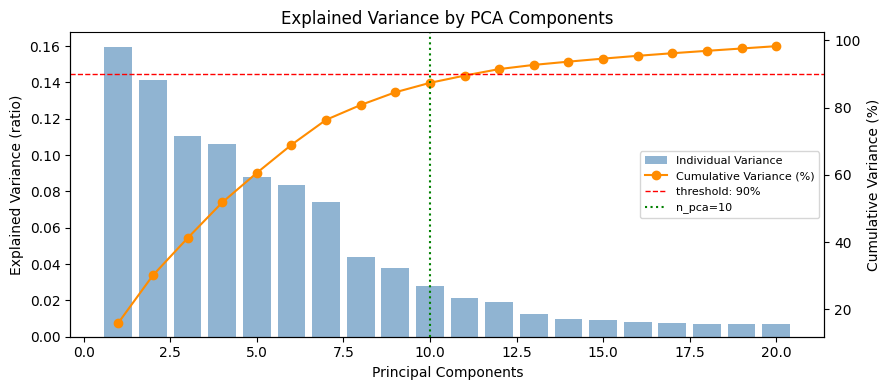

           Age  FamilySize    Income    Wealth      Debt    FinEdu       ESG  \
PC1   0.121860   -0.024451 -0.121018 -0.116990 -0.156136 -0.117725 -0.005843   
PC2   0.113456    0.014637 -0.090050 -0.088602 -0.109716 -0.087994 -0.031400   
PC3  -0.004975    0.012483 -0.000877 -0.001326 -0.006327 -0.003987 -0.007979   
PC4  -0.053829   -0.103620  0.085673  0.083403  0.014554  0.082492  0.064094   
PC5   0.078597   -0.028333 -0.052363 -0.062262 -0.070935 -0.050357  0.008917   
PC6  -0.047897    0.066569 -0.000767 -0.003559  0.055320  0.001291 -0.037167   
PC7   0.022023    0.091845 -0.019670 -0.006381  0.054392 -0.004643 -0.049362   
PC8  -0.186465    0.049191  0.102213  0.087225  0.073156  0.043239 -0.039139   
PC9   0.027796    0.054512 -0.028651 -0.018733 -0.001659 -0.022698 -0.014014   
PC10 -0.238018   -0.252756  0.238617  0.221377  0.144859  0.231071  0.151308   

       Digital  BankFriend  LifeStyle  ...     Job_5    Area_1    Area_2  \
PC1  -0.133422   -0.030649  -0.124410  ... 

In [10]:
# Call to the previous function
df_pca, pca, loadings, n_pca, cum_var = apply_pca_with_variance_threshold(df_standardized)

# Number of components to display
n_display = min(20, len(cum_var))

# Individual explained variance (of the final PCA)
explained_var = pca.explained_variance_ratio_

# Graph
fig, ax = plt.subplots(figsize=(9, 4))

# Bars (individual variance)
ax.bar(
    range(1, len(explained_var[:n_display]) + 1),
    explained_var[:n_display],
    alpha=0.6,
    color="steelblue",
    label="Individual Variance"
)

# Cumulative curve
ax2 = ax.twinx()
ax2.plot(
    range(1, len(cum_var[:n_display]) + 1),
    cum_var[:n_display] * 100,
    marker="o",
    color="darkorange",
    label="Cumulative Variance (%)"
)

# Threshold (dynamically adjusted)
threshold_percent = 90  # ou ton variance_threshold * 100
ax2.axhline(threshold_percent, linestyle="--", color="red", linewidth=1, label=f"threshold: {threshold_percent}%")

# Vertical line for n_pca
ax2.axvline(n_pca, linestyle=":", color="green", linewidth=1.5, label=f"n_pca={n_pca}")

# Labels
ax.set_xlabel("Principal Components")
ax.set_ylabel("Explained Variance (ratio)")
ax2.set_ylabel("Cumulative Variance (%)")
ax.set_title("Explained Variance by PCA Components")

# Combined legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="center right")

# Style
ax.spines[["top"]].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "gmm_pca_scree.png"), dpi=150)
plt.show()


print(loadings)

However, we currently have a problem. We cannot apply this algorithm to df_gower, whose categorical columns are not standardized with OneHotEncoder, which skews the distances. The variances on the categorical variables appear much larger and artificially inflate the variance. For the second, df_standardized, PCA is mathematically correct but biased, because the categorical variables with high cardinality take up too much space and dominate the variance.

Rather than choosing between these two imperfect options, we adopt a new approach: we use PCA only for numerical variables (where it is relevant) and we measure the importance of the categorical variables via their entropy. We then combine these two types of information to obtain an overall importance of the features, and then aggregate in blocks to construct consistent weights adapted to the Gower distance.

In [11]:
def compute_numeric_importance_pca(df_numerical):
    df_pca, pca_full, loadings, n_pca, cum_var = apply_pca_with_variance_threshold(df_num)
    # Compute weighted loadings:
    # For each component k and feature j, importance contribution = |loading_kj| * explained_variance_k
    weighted_loadings = np.abs(loadings.values) * (cum_var[:n_pca] - np.concatenate(([0], cum_var[:n_pca-1])))[:, None]
    feature_importance_num = weighted_loadings.sum(axis=0)

    return pd.Series(feature_importance_num, index=df_num.columns)


def compute_categorical_importance_entropy(df_categorical):
    
    # Dictionary to store importance scores for each feature
    importance = {}

    for col in df_categorical.columns:

        # Compute the probability distribution of categories
        probs = df_categorical[col].value_counts(normalize=True)

        # Compute Shannon entropy (a small constant (1e-9) is added to avoid log(0))
        entropy = -np.sum(probs * np.log(probs + 1e-9))

        # Normalize entropy to be between 0 and 1
        # It allows comparison across variables with different cardinalities
        entropy /= np.log(len(probs) + 1e-9)

        importance[col] = entropy

    return pd.Series(importance)

def combine_importances(num_imp, cat_imp):
    
    # Concatenate numerical and categorical importances into a single Series
    # This creates a unified importance vector across all features
    importance = pd.concat([num_imp, cat_imp])
    
    # Concatenate numerical and categorical importances into a single Series
    # This creates a unified importance vector across all features
    importance /= importance.sum()
    return importance


def compute_block_weights(importance, feature_blocks):
    block_importance = {}

    # Loop over each feature and its importance score
    for col, val in importance.items():

        # Retrieve the block associated with the feature
        # If not found, assign it to a default "other" block
        block = feature_blocks.get(col, "other")
        block_importance[block] = block_importance.get(block, 0) + val

    total = sum(block_importance.values())
    # Normalize block importance to obtain weights
    # Each block weight represents its relative importance
    weight_scheme = {k: v / total for k, v in block_importance.items()}

    return weight_scheme, pd.Series(block_importance)

In [12]:
df_num = df_gower[numeric_cols].copy()
df_cat = df_gower[categorical_cols].copy()

num_imp = compute_numeric_importance_pca(df_num)
cat_imp = compute_categorical_importance_entropy(df_cat)

importance = combine_importances(num_imp, cat_imp)

weight_scheme, block_importance = compute_block_weights(importance, FEATURE_BLOCKS)

print(importance)

print(weight_scheme)

Components needed to reach 90% variance: 9
Number of components selected: 9
Cumulative explained variance: 90.2%
Shape after PCA: (5000, 9)
Age            0.040029
FamilySize     0.028732
Income         0.031949
Wealth         0.031772
Debt           0.035399
FinEdu         0.021743
ESG            0.022731
Digital        0.026519
BankFriend     0.028137
LifeStyle      0.031090
Luxury         0.036394
Saving         0.025914
Gender         0.148560
Job            0.094287
Area           0.104774
CitySize       0.146432
Investments    0.145540
dtype: float64
{'demographic': 0.5628138649618231, 'financial': 0.12503344051589313, 'behavioral': 0.3121526945222839}


## 7) Determination of Weights

In [13]:
# Definition of different feature weighting schemes used to influence clustering
# Each scheme assigns a relative importance to demographic, financial, and behavioral variables
# We propose several weight distributions to measure the performance of those proposed by the PCA-enthropy method developed above. 
# This also allows us to adapt the segmentation to different business objectives (e.g., financial analysis vs. behavioral segmentation)

WEIGHT_SCHEMES = {

    # Weight distribution obtained by the entropy-pca method
    "recommended_weight":{
        "demographic": 0.5628138649618231, 
        "financial": 0.12503344051589313, 
        "behavioral": 0.3121526945222839},
    
    # All feature groups have equal importance
    "equal": {
        "demographic": 0.3333,
        "financial": 0.3333,
        "behavioral": 0.3333
    },
    # Financial variables are emphasized
    "financial_focus": {
        "demographic": 0.1667,
        "financial": 0.5000,
        "behavioral": 0.3333
    },
    # Behavioral variables are emphasized
    "behavioral_focus": {
        "demographic": 0.1667,
        "financial": 0.3333,
        "behavioral": 0.5000
    },
    # Demographic variables are emphasized
    "behavioral_focus": {
        "financial": 0.1667,
        "behavioral": 0.3333,
        "demographic": 0.5000
    }
}

## 8) Distance functions

In [14]:
# Assign a weight to each characteristic based on its type (demographic, financial, behavioral) defined from one of the FEATURE_BLOCKS dictionaries
# If a variable isn't found in FEATURE_BLOCKS, it is assigned the class "behavioral"
def feature_weights_from_scheme(columns: List[str], scheme: Dict[str, float]) -> np.ndarray:
    weights = []
    for col in columns:
        
        # If the column is known, its type is retrieved from the FEATURE_BLOCKS dictionary; otherwise, "behavioral" is applied to it
        block = FEATURE_BLOCKS.get(col, "behavioral")

        # Retrieve the weights defined in the WEIGHT_SCHEMES dictionary used
        weights.append(float(scheme.get(block, 1.0)))
    return np.asarray(weights, dtype=np.float32)

# Construct a distance matrix between all observations using Gower's distance to accommodate both numerical and categorical variables
def compute_gower_distance_matrix(df: pd.DataFrame, numeric_cols: List[str], categorical_cols: List[str], block_weight_scheme: Optional[Dict[str, float]] = None) -> np.ndarray:
    n = len(df)
    D = np.zeros((n, n), dtype=np.float32)

    # If no weighting scheme is applied, all variables have the same weight
    if block_weight_scheme is None:
        num_weights = np.ones(len(numeric_cols), dtype=np.float32)
        cat_weights = np.ones(len(categorical_cols), dtype=np.float32)
    else:
        num_weights = feature_weights_from_scheme(numeric_cols, block_weight_scheme)
        cat_weights = feature_weights_from_scheme(categorical_cols, block_weight_scheme)
        
    total_weight = float(num_weights.sum() + cat_weights.sum())

    # The weights are applied both on numeric numerical and categorical data according to its type
    # For numerical variables, it uses the absolute difference between values
    if numeric_cols:
        x_num = df[numeric_cols].astype(np.float32)
        for idx, col in enumerate(numeric_cols):
            values = x_num[col].to_numpy(dtype=np.float32)
            D += num_weights[idx] * np.abs(values[:, None] - values[None, :])

    # For categorical variables, it assigns a distance of 0 if the values are identical and 1 otherwise
    if categorical_cols:
        for idx, col in enumerate(categorical_cols):
            values = df[col].astype(str).to_numpy()
            D += cat_weights[idx] * (values[:, None] != values[None, :]).astype(np.float32)
            
    # The total distance is normalized by the sum of all weights
    D /= max(total_weight, 1.0)
    return D

## 9) K-Medoids functions

In [15]:
from typing import Dict, List, Optional
import numpy as np
import pandas as pd
from sklearn_extra.cluster import KMedoids


def run_kmedoids_with_weight_schemes(df: pd.DataFrame, numeric_cols: List[str], categorical_cols: List[str], weight_schemes: Dict[str, Dict[str, float]],n_clusters: int, max_iter: int = 300, verbose: bool = True) -> Dict[str, dict]:
    
    all_results = {}

    for scheme_name, scheme in weight_schemes.items():
        
        if verbose:
            print(f"\n===== Scheme: {scheme_name} =====")

        # Compute distance matrix
        D = compute_gower_distance_matrix(
            df=df,
            numeric_cols=numeric_cols,
            categorical_cols=categorical_cols,
            block_weight_scheme=scheme
        )

        # Fit KMedoids
        model = KMedoids(
            n_clusters=n_clusters,
            metric="precomputed",
            method="pam",
            init="k-medoids++",
            random_state=RANDOM_STATE,
            max_iter=max_iter
        )

        model.fit(D)

        labels = model.labels_
        medoids = model.medoid_indices_

        # Build clustered dataframe
        df_clustered = df.copy()
        df_clustered["cluster"] = labels
        df_clustered["distance_to_medoid"] = D[np.arange(len(D)), medoids[labels]]

        medoids_df = df_clustered.iloc[medoids].copy()

        # Store results
        result = {
            "distance_matrix": D,
            "labels": labels,
            "medoids": medoids,
            "df_clustered": df_clustered,
            "medoids_df": medoids_df,
            "cluster_sizes": df_clustered["cluster"].value_counts().sort_index(),
            "cluster_means": df_clustered.groupby("cluster")[numeric_cols].mean()
        }

        all_results[scheme_name] = result

        # Print
        if verbose:
            print("Cluster size:")
            print(result["cluster_sizes"])

            print("\nMedoids:")
            print(medoids_df)

            print("\nAverage of features per cluster:")
            print(result["cluster_means"])

    return all_results

In [16]:
results = run_kmedoids_with_weight_schemes(
    df=df_gower,
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    weight_schemes=WEIGHT_SCHEMES,
    n_clusters=4,
)


===== Scheme: recommended_weight =====


C:\Users\Maxime\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


Cluster size:
cluster
0    1189
1    1478
2     895
3    1438
Name: count, dtype: int64

Medoids:
           Age  Gender  Job  Area  CitySize  FamilySize    Income    Wealth  \
2154  0.421053       0    2     1         3         0.2  0.831359  0.815864   
528   0.618421       1    2     1         2         0.4  0.782735  0.685439   
2832  0.802632       1    5     1         2         0.0  0.348810  0.378957   
700   0.460526       0    2     1         1         0.2  0.702954  0.560029   

          Debt    FinEdu       ESG   Digital  BankFriend  LifeStyle    Luxury  \
2154  0.553101  0.686388  0.736517  0.733108    0.691409   0.747903  0.872905   
528   0.492933  0.588993  0.566626  0.505026    0.452415   0.513859  0.470922   
2832  0.036310  0.401342  0.630642  0.249188    0.421981   0.246924  0.227880   
700   0.496597  0.457787  0.635905  0.602940    0.587732   0.377063  0.601081   

        Saving  Investments  cluster  distance_to_medoid  
2154  0.737376            3        0     

C:\Users\Maxime\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


Cluster size:
cluster
0    1231
1     886
2    1383
3    1500
Name: count, dtype: int64

Medoids:
           Age  Gender  Job  Area  CitySize  FamilySize    Income    Wealth  \
2154  0.421053       0    2     1         3         0.2  0.831359  0.815864   
1088  0.710526       1    5     1         2         0.0  0.414356  0.229194   
126   0.473684       1    2     1         1         0.2  0.465843  0.519142   
252   0.539474       0    2     1         2         0.4  0.442979  0.608589   

          Debt    FinEdu       ESG   Digital  BankFriend  LifeStyle    Luxury  \
2154  0.553101  0.686388  0.736517  0.733108    0.691409   0.747903  0.872905   
1088  0.199033  0.396549  0.727656  0.345245    0.701487   0.221319  0.205832   
126   0.447605  0.436480  0.576135  0.510305    0.402519   0.293335  0.415133   
252   0.546616  0.412240  0.484276  0.507173    0.421154   0.521516  0.252750   

        Saving  Investments  cluster  distance_to_medoid  
2154  0.737376            3        0     

C:\Users\Maxime\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


Cluster size:
cluster
0    1180
1     934
2    1208
3    1678
Name: count, dtype: int64

Medoids:
           Age  Gender  Job  Area  CitySize  FamilySize    Income    Wealth  \
2154  0.421053       0    2     1         3         0.2  0.831359  0.815864   
373   1.000000       1    5     1         2         0.2  0.400569  0.417788   
1666  0.447368       0    2     1         1         0.0  0.616988  0.419930   
3176  0.921053       1    2     1         2         0.4  0.515559  0.570811   

          Debt    FinEdu       ESG   Digital  BankFriend  LifeStyle    Luxury  \
2154  0.553101  0.686388  0.736517  0.733108    0.691409   0.747903  0.872905   
373   0.113767  0.386123  0.800800  0.390388    0.585799   0.159289  0.271638   
1666  0.453937  0.578175  0.529859  0.501882    0.524254   0.604049  0.315958   
3176  0.441176  0.492556  0.670638  0.637575    0.455124   0.354472  0.429760   

        Saving  Investments  cluster  distance_to_medoid  
2154  0.737376            3        0     

C:\Users\Maxime\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


Cluster size:
cluster
0     878
1    1230
2    1670
3    1222
Name: count, dtype: int64

Medoids:
           Age  Gender  Job  Area  CitySize  FamilySize    Income    Wealth  \
2832  0.802632       1    5     1         2         0.0  0.348810  0.378957   
126   0.473684       1    2     1         1         0.2  0.465843  0.519142   
252   0.539474       0    2     1         2         0.4  0.442979  0.608589   
3256  0.447368       1    2     1         3         0.0  0.755743  0.918241   

          Debt    FinEdu       ESG   Digital  BankFriend  LifeStyle    Luxury  \
2832  0.036310  0.401342  0.630642  0.249188    0.421981   0.246924  0.227880   
126   0.447605  0.436480  0.576135  0.510305    0.402519   0.293335  0.415133   
252   0.546616  0.412240  0.484276  0.507173    0.421154   0.521516  0.252750   
3256  0.591154  0.858227  0.696037  0.759862    0.672911   0.738852  0.730757   

        Saving  Investments  cluster  distance_to_medoid  
2832  0.446930            2        0     

In [54]:
# Number of individuals in each cluster
results["equal"]["cluster_sizes"]

cluster
0    1231
1     886
2    1383
3    1500
Name: count, dtype: int64

In [57]:
# Display a DataFrame containing the medoids
results["financial_focus"]["medoids_df"]

,Age,Gender,Job,Area,CitySize,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving,Investments,cluster,distance_to_medoid
2154,0.421053,0,2,1,3,0.2,0.831359,0.815864,0.553101,0.686388,0.736517,0.733108,0.691409,0.747903,0.872905,0.737376,3,0,0.0
373,1.000000,1,5,1,2,0.2,0.400569,0.417788,0.113767,0.386123,0.800800,0.390388,0.585799,0.159289,0.271638,0.343404,2,1,0.0
1666,0.447368,0,2,1,1,0.0,0.616988,0.419930,0.453937,0.578175,0.529859,0.501882,0.524254,0.604049,0.315958,0.538388,1,2,0.0
3176,0.921053,1,2,1,2,0.4,0.515559,0.570811,0.441176,0.492556,0.670638,0.637575,0.455124,0.354472,0.429760,0.596167,3,3,0.0


In [58]:
# Average profile of each cluster
results["recommended_weight"]["cluster_means"]

,Age,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving
cluster,,,,,,,,,,,,
0,0.418828,0.208410,0.747580,0.741958,0.552585,0.697307,0.654236,0.739372,0.687493,0.653563,0.701745,0.608544
1,0.513407,0.374560,0.584056,0.581635,0.482509,0.530816,0.538627,0.552808,0.537228,0.476766,0.471957,0.569259
2,0.784358,0.199777,0.419746,0.423557,0.171706,0.366239,0.603846,0.328294,0.594689,0.272093,0.281888,0.366160
3,0.534212,0.353408,0.557168,0.547998,0.468853,0.495912,0.527560,0.503763,0.535228,0.420526,0.417583,0.560496


In [46]:
for name, res in results.items():
    print(f"{name}: {np.bincount(res['labels'])}")

recommended_weight: [1189 1478  895 1438]
equal: [1231  886 1383 1500]
financial_focus: [1180  934 1208 1678]
behavioral_focus: [1046 1248 1030 1676]


In [49]:
def plot_all_kmedoids_results_3d(
    results: dict,
    method: str = "tsne",
    figsize: tuple = (18, 10),
    random_state: int = 42
):

    n_schemes = len(results)
    ncols = 3
    nrows = int(np.ceil(n_schemes / ncols))

    fig = plt.figure(figsize=figsize)

    # Palette simple
    colors = ['blue', '#4DBEEE', '#77AC30', '#EDB120', '#D95319', '#7E2F8E', '#A2142F']

    for idx, (scheme_name, res) in enumerate(results.items(), start=1):
        D = res["distance_matrix"]
        labels = res["labels"]
        medoids = res["medoids"]

        # Projection 3D
        if method.lower() == "tsne":
            # perplexity doit être < n_samples
            perplexity = min(30, max(5, len(D) // 10))
            perplexity = min(perplexity, len(D) - 1)

            reducer = TSNE(
                n_components=3,
                metric="precomputed",
                init="random",
                random_state=random_state,
                perplexity=perplexity
            )
            Y_3d = reducer.fit_transform(D)

        elif method.lower() == "mds":
            from sklearn.manifold import MDS
            reducer = MDS(
                n_components=3,
                metric="precomputed",
                n_init=1,
                max_iter=120,
                random_state=random_state
            )
            Y_3d = reducer.fit_transform(D)

        else:
            raise ValueError("method must be either 'tsne' or 'mds'")

        ax = fig.add_subplot(nrows, ncols, idx, projection='3d')

        k = len(np.unique(labels))

        for cluster_id in range(k):
            mask = labels == cluster_id
            ax.scatter(
                Y_3d[mask, 0],
                Y_3d[mask, 1],
                Y_3d[mask, 2],
                c=colors[cluster_id % len(colors)],
                edgecolor='k',
                alpha=0.8,
                s=35,
                label=f'Cluster {cluster_id + 1}'
            )

        # Medoids
        ax.scatter(
            Y_3d[medoids, 0],
            Y_3d[medoids, 1],
            Y_3d[medoids, 2],
            c='red',
            marker='X',
            s=180,
            edgecolor='k',
            label='Medoids'
        )

        ax.set_title(f"{scheme_name}")
        ax.set_xlabel("Dim 1")
        ax.set_ylabel("Dim 2")
        ax.set_zlabel("Dim 3")
        ax.view_init(elev=15, azim=-30)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

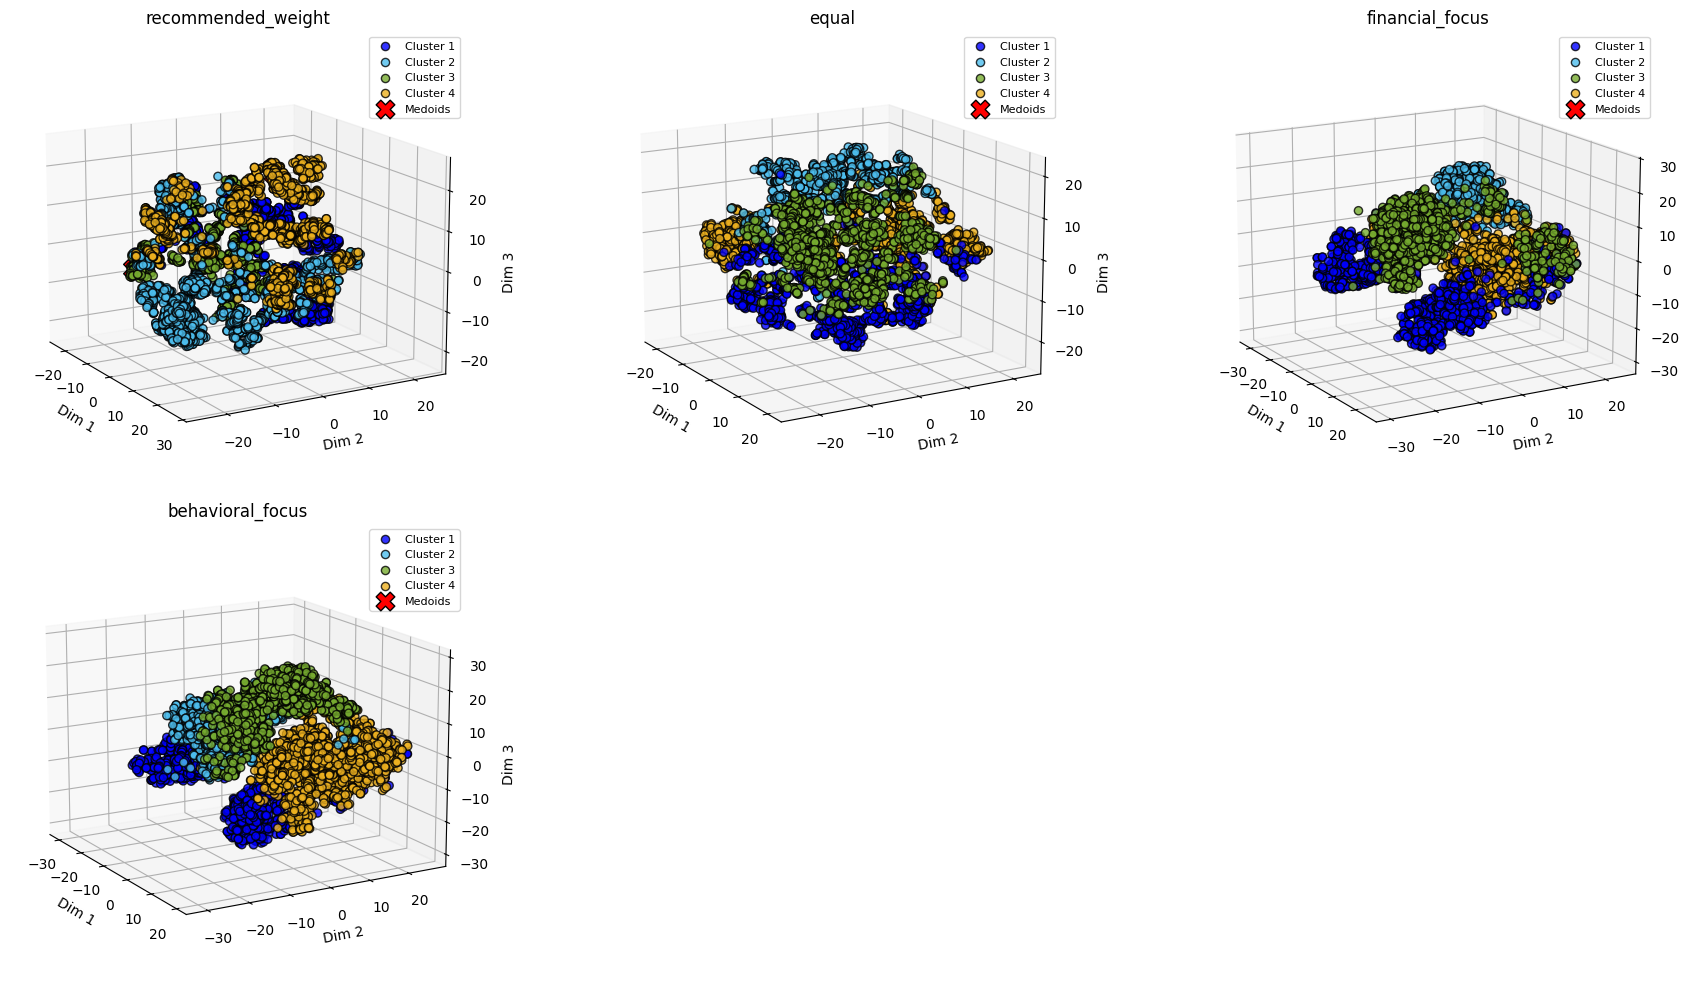

In [60]:
plot_all_kmedoids_results_3d(results, method="tsne")

## 10) Evaluation Metrics

In [17]:
def _build_encoded_matrix(
    df: pd.DataFrame,
    numeric_cols: List[str],
    categorical_cols: List[str],
) -> np.ndarray:
    """Build a fully numeric matrix for sklearn metrics and Euclidean baselines."""
    parts = []

    if numeric_cols:
        num_df = df[numeric_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)
        parts.append(num_df.to_numpy(dtype=np.float64))

    if categorical_cols:
        cat_df = (
            df[categorical_cols]
            .copy()
            .fillna("__missing__")
            .astype(str)
        )
        parts.append(pd.get_dummies(cat_df, columns=categorical_cols, dummy_na=False).to_numpy(dtype=np.float64))

    if not parts:
        return np.empty((len(df), 0), dtype=np.float64)

    return np.concatenate(parts, axis=1)


def safe_internal_metrics(
    X_encoded: np.ndarray,
    labels: np.ndarray,
    distance_matrix: Optional[np.ndarray] = None
) -> Dict[str, float]:
    labels = np.asarray(labels)
    if len(labels) < 3 or len(np.unique(labels)) < 2:
        return {"silhouette": np.nan, "calinski_harabasz": np.nan, "davies_bouldin": np.nan}

    try:
        if distance_matrix is not None and distance_matrix.shape[0] == len(labels):
            sil = float(
                silhouette_score(
                    distance_matrix,
                    labels,
                    metric="precomputed",
                    sample_size=min(SILHOUETTE_SAMPLE_SIZE, len(labels)),
                    random_state=RANDOM_STATE,
                )
            )
        else:
            sil = float(
                silhouette_score(
                    X_encoded,
                    labels,
                    sample_size=min(SILHOUETTE_SAMPLE_SIZE, len(labels)),
                    random_state=RANDOM_STATE,
                )
            )
    except Exception:
        sil = np.nan

    try:
        ch = float(calinski_harabasz_score(X_encoded, labels))
    except Exception:
        ch = np.nan

    try:
        db = float(davies_bouldin_score(X_encoded, labels))
    except Exception:
        db = np.nan

    return {"silhouette": sil, "calinski_harabasz": ch, "davies_bouldin": db}


def _normalize_series(s: pd.Series, higher_is_better: bool = True) -> pd.Series:
    s = pd.to_numeric(s, errors="coerce").astype(float)

    if s.isna().all():
        return pd.Series(np.zeros(len(s)), index=s.index, dtype=float)

    s_min = float(s.min(skipna=True))
    s_max = float(s.max(skipna=True))

    if math.isclose(s_min, s_max):
        out = pd.Series(np.ones(len(s)), index=s.index, dtype=float)
    else:
        out = (s - s_min) / (s_max - s_min)

    out = out.fillna(0.0)
    return out if higher_is_better else 1.0 - out


def _safe_best_k(kmed_df: pd.DataFrame, column: str, mode: str) -> Optional[int]:
    series = pd.to_numeric(kmed_df[column], errors="coerce")
    valid = kmed_df.loc[series.notna(), ["k", column]].copy()
    if valid.empty:
        return None
    if mode == "max":
        idx = valid[column].astype(float).idxmax()
    else:
        idx = valid[column].astype(float).idxmin()
    return int(valid.loc[idx, "k"])


def choose_k_with_overlay(kmed_df: pd.DataFrame) -> Tuple[int, pd.DataFrame, List[str]]:
    if kmed_df.empty:
        raise ValueError("choose_k_with_overlay received an empty K-Medoids benchmark table.")

    notes: List[str] = []

    ch_opt = _safe_best_k(kmed_df, "calinski_harabasz", "max")
    db_opt = _safe_best_k(kmed_df, "davies_bouldin", "min")
    sil_opt = _safe_best_k(kmed_df, "silhouette", "max")

    votes = [k for k in [ch_opt, db_opt, sil_opt] if k is not None]
    vote_k = int(np.median(votes)) if votes else int(kmed_df["k"].median())

    ranked = kmed_df.copy()
    ranked["sil_n"] = _normalize_series(ranked["silhouette"], True)
    ranked["ch_n"] = _normalize_series(ranked["calinski_harabasz"], True)
    ranked["db_n"] = _normalize_series(ranked["davies_bouldin"], False)
    ranked["cost_n"] = _normalize_series(ranked["total_cost"], False)
    ranked["minshare_n"] = _normalize_series(ranked["min_cluster_share"], True)
    ranked["composite_score"] = (
        0.35 * ranked["sil_n"]
        + 0.25 * ranked["ch_n"]
        + 0.15 * ranked["db_n"]
        + 0.15 * ranked["cost_n"]
        + 0.10 * ranked["minshare_n"]
    )
    ranked = ranked.sort_values(["composite_score", "silhouette", "k"], ascending=[False, False, True]).reset_index(drop=True)

    top_composite_k = int(ranked.loc[0, "k"])

    metric_note_parts = []
    if ch_opt is not None:
        metric_note_parts.append(f"CH={ch_opt}")
    if db_opt is not None:
        metric_note_parts.append(f"DB={db_opt}")
    if sil_opt is not None:
        metric_note_parts.append(f"Silhouette={sil_opt}")
    if metric_note_parts:
        notes.append(f"Metric vote suggests k={vote_k} ({', '.join(metric_note_parts)}).")
    else:
        notes.append("All internal metrics were unavailable, so selection relies on the composite fallback.")

    notes.append(f"Best composite-score candidate is k={top_composite_k}.")

    chosen_k = top_composite_k
    usable = ranked[(ranked["k"].between(5, 7)) & (ranked["min_cluster_share"] >= 0.08)].copy()
    if not usable.empty:
        best_all = float(ranked["composite_score"].max())
        usable_close = usable[usable["composite_score"] >= best_all - 0.03].copy()
        if not usable_close.empty:
            chosen_k = int(
                usable_close.sort_values(["composite_score", "silhouette", "k"], ascending=[False, False, True]).iloc[0]["k"]
            )
            notes.append("Qualitative overlay applied: chose a business-usable k in the 5-7 range with no tiny clusters.")
        else:
            notes.append("Qualitative overlay checked but the top candidate remained clearly superior.")
    else:
        notes.append("No 5-7 cluster solution met the minimum cluster-share constraint.")

    return chosen_k, ranked, notes


def benchmark_models(
    df: pd.DataFrame,
    numeric_cols: List[str],
    categorical_cols: List[str],
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, int, List[str], np.ndarray, np.ndarray, np.ndarray]:
    if len(df) < 3:
        raise ValueError("benchmark_models needs at least 3 rows.")

    rng = np.random.default_rng(RANDOM_STATE)
    sample_n = min(BENCHMARK_SAMPLE_SIZE, len(df))
    sample_index = np.sort(rng.choice(len(df), size=sample_n, replace=False))
    sample_df = df.iloc[sample_index].reset_index(drop=True)

    X_sample = _build_encoded_matrix(sample_df, numeric_cols, categorical_cols)
    D_sample = compute_gower_distance_matrix(sample_df, numeric_cols, categorical_cols, WEIGHT_SCHEMES["equal"])

    valid_k_values = [int(k) for k in CANDIDATE_K if 2 <= int(k) < len(sample_df)]
    if not valid_k_values:
        raise ValueError("No valid k in CANDIDATE_K for the sampled dataset size.")

    rows = []
    for k in valid_k_values:
        try:
            km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
            labels = km.fit_predict(X_sample)
            metrics = safe_internal_metrics(X_sample, labels)
            rows.append({
                "method": "kmeans_encoded",
                "k": k,
                "total_cost": float(km.inertia_),
                "min_cluster_share": float(pd.Series(labels).value_counts(normalize=True).min()),
                **metrics,
                "notes": "Useful benchmark, but less natural for mixed data.",
            })
        except Exception as exc:
            rows.append({
                "method": "kmeans_encoded",
                "k": k,
                "total_cost": np.nan,
                "min_cluster_share": np.nan,
                "silhouette": np.nan,
                "calinski_harabasz": np.nan,
                "davies_bouldin": np.nan,
                "notes": f"K-Means failed: {exc}",
            })

    for k in valid_k_values:
        try:
            ag = AgglomerativeClustering(n_clusters=k, metric="precomputed", linkage="average")
            labels = ag.fit_predict(D_sample)
            metrics = safe_internal_metrics(X_sample, labels, D_sample)
            rows.append({
                "method": "agglomerative_gower",
                "k": k,
                "total_cost": np.nan,
                "min_cluster_share": float(pd.Series(labels).value_counts(normalize=True).min()),
                **metrics,
                "notes": "Useful mixed-data alternative; hierarchy is informative.",
            })
        except Exception as exc:
            rows.append({
                "method": "agglomerative_gower",
                "k": k,
                "total_cost": np.nan,
                "min_cluster_share": np.nan,
                "silhouette": np.nan,
                "calinski_harabasz": np.nan,
                "davies_bouldin": np.nan,
                "notes": f"Agglomerative failed: {exc}",
            })

    for k in valid_k_values:
        try:
            result = kmedoids(D_sample, k=k, max_iter=50, random_state=RANDOM_STATE)
            metrics = safe_internal_metrics(X_sample, result.labels, D_sample)
            rows.append({
                "method": "kmedoids_gower",
                "k": k,
                "total_cost": float(result.total_cost),
                "min_cluster_share": float(pd.Series(result.labels).value_counts(normalize=True).min()),
                **metrics,
                "notes": "Best fit for mixed data and easiest to explain through real medoids.",
            })
        except Exception as exc:
            rows.append({
                "method": "kmedoids_gower",
                "k": k,
                "total_cost": np.nan,
                "min_cluster_share": np.nan,
                "silhouette": np.nan,
                "calinski_harabasz": np.nan,
                "davies_bouldin": np.nan,
                "notes": f"K-Medoids failed: {exc}",
            })

    benchmark_df = pd.DataFrame(rows)

    dbscan_rows = []
    for eps in DBSCAN_EPS_GRID:
        try:
            db = DBSCAN(eps=eps, min_samples=DBSCAN_MIN_SAMPLES, metric="precomputed")
            labels = db.fit_predict(D_sample)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            noise_share = float(np.mean(labels == -1))
            sil = np.nan
            if n_clusters >= 2 and noise_share < 0.40:
                keep = labels != -1
                try:
                    sil = float(
                        silhouette_score(
                            D_sample[np.ix_(keep, keep)],
                            labels[keep],
                            metric="precomputed",
                            sample_size=min(SILHOUETTE_SAMPLE_SIZE, int(keep.sum())),
                            random_state=RANDOM_STATE,
                        )
                    )
                except Exception:
                    sil = np.nan
            dbscan_rows.append({
                "method": "dbscan_gower",
                "eps": eps,
                "min_samples": DBSCAN_MIN_SAMPLES,
                "n_clusters": int(n_clusters),
                "noise_share": noise_share,
                "silhouette_non_noise": sil,
            })
        except Exception as exc:
            dbscan_rows.append({
                "method": "dbscan_gower",
                "eps": eps,
                "min_samples": DBSCAN_MIN_SAMPLES,
                "n_clusters": np.nan,
                "noise_share": np.nan,
                "silhouette_non_noise": np.nan,
            })
    dbscan_df = pd.DataFrame(dbscan_rows)

    nn_k = min(DBSCAN_MIN_SAMPLES, len(D_sample))
    nn = NearestNeighbors(n_neighbors=nn_k, metric="precomputed")
    nn.fit(D_sample)
    distances, _ = nn.kneighbors(D_sample)
    knn_curve_df = pd.DataFrame({
        "rank": np.arange(1, len(D_sample) + 1),
        "distance_to_kth_neighbor": np.sort(distances[:, -1]),
    })

    kmed_df = benchmark_df[benchmark_df["method"] == "kmedoids_gower"].copy().reset_index(drop=True)
    chosen_k, _, selection_notes = choose_k_with_overlay(kmed_df)

    return benchmark_df, dbscan_df, knn_curve_df, chosen_k, selection_notes, sample_index, X_sample, D_sample

## 8) Robustness functions

In [41]:
from types import SimpleNamespace

def kmedoids(D, k, max_iter=300, random_state=42):
    model = KMedoids(
        n_clusters=k,
        metric="precomputed",
        random_state=random_state,
        init="k-medoids++",
        max_iter=max_iter
    )
    labels = model.fit_predict(D)
    
    return SimpleNamespace(
    labels=labels,
    medoids=model.medoid_indices_,
    model=model,
    total_cost=float(model.inertia_)
)

In [42]:
def cluster_stability_check(
    sample_df: pd.DataFrame,
    numeric_cols: List[str],
    categorical_cols: List[str],
    chosen_k: int,
    n_runs: int = 6,
) -> pd.DataFrame:
    D = compute_gower_distance_matrix(sample_df, numeric_cols, categorical_cols, WEIGHT_SCHEMES["equal"])
    reference = kmedoids(D, k=chosen_k, max_iter=50, random_state=RANDOM_STATE)
    rows = []
    for run in range(1, n_runs + 1):
        result = kmedoids(D, k=chosen_k, max_iter=50, random_state=RANDOM_STATE + run)
        rows.append({
            "run": run,
            "ari_vs_reference": float(adjusted_rand_score(reference.labels, result.labels)),
            "min_cluster_share": float(pd.Series(result.labels).value_counts(normalize=True).min()),
            "total_cost": float(result.total_cost),
        })
    return pd.DataFrame(rows)


def weighted_sensitivity_check(
    sample_df: pd.DataFrame,
    numeric_cols: List[str],
    categorical_cols: List[str],
    chosen_k: int,
    reference_labels: np.ndarray,
    X_sample: np.ndarray,
) -> pd.DataFrame:
    rows = []
    for scheme_name, scheme in WEIGHT_SCHEMES.items():
        D = compute_gower_distance_matrix(sample_df, numeric_cols, categorical_cols, scheme)
        result = kmedoids(D, k=chosen_k, max_iter=50, random_state=RANDOM_STATE)
        metrics = safe_internal_metrics(X_sample, result.labels, D)
        ari = np.nan if scheme_name == "equal" else float(adjusted_rand_score(reference_labels, result.labels))
        rows.append({
            "scheme": scheme_name,
            "demographic_weight": scheme["demographic"],
            "financial_weight": scheme["financial"],
            "behavioral_weight": scheme["behavioral"],
            "ari_vs_equal_gower": ari,
            "min_cluster_share": float(pd.Series(result.labels).value_counts(normalize=True).min()),
            "total_cost": float(result.total_cost),
            **metrics,
        })
    return pd.DataFrame(rows)

## 9) Profiling functions

In [43]:
# -----------------------------------------------------------------------------
# PROFILING
# -----------------------------------------------------------------------------
def mode_with_share(series: pd.Series) -> Tuple[object, float]:
    vc = series.value_counts(normalize=True, dropna=False)
    if vc.empty:
        return np.nan, np.nan
    top_value = vc.index[0]
    if pd.isna(top_value):
        top_value = "__missing__"
    return top_value, float(vc.iloc[0])


def generate_persona_name(profile: pd.Series) -> str:
    age = float(profile.get("Age_mean", np.nan))
    wealth_delta = float(profile.get("Wealth_delta_vs_overall", 0.0))
    digital_delta = float(profile.get("Digital_delta_vs_overall", 0.0))
    family_delta = float(profile.get("FamilySize_delta_vs_overall", 0.0))
    gender_mode = str(profile.get("Gender_mode", "Unknown"))
    area_mode = str(profile.get("Area_mode", "Unknown"))
    city_mode = str(profile.get("CitySize_mode", "Unknown"))
    job_mode = str(profile.get("Job_mode", "Unknown"))
    inv_mode = str(profile.get("Investments_mode", "Unknown"))

    if pd.notna(age) and age >= 75:
        return "Very Senior Conservative Retirees"
    if job_mode == "Retired" or (pd.notna(age) and age >= 66 and digital_delta < -0.10):
        return "Late-Career Conservative Households"
    if inv_mode == "No investments" and pd.notna(age) and age >= 65:
        return "Late-Career / Pre-Retirement Non-Investors"
    if wealth_delta > 0.12 and digital_delta > 0.12 and city_mode == "Large city":
        return "Affluent Digital Urban Professionals"
    if gender_mode == "Female" and wealth_delta > 0.00 and digital_delta > 0.05:
        return "Affluent Practical Women"
    if family_delta > 0.40:
        return "Mature Mainstream Families"
    if area_mode == "South/Islands" and city_mode == "Small town":
        return "Traditional Southern Households"
    return "Balanced Everyday Retail Clients"


def ensure_unique_persona_names(profiles: pd.DataFrame) -> pd.DataFrame:
    profiles = profiles.copy()
    counts = profiles["Persona"].value_counts()
    dupes = counts[counts > 1].index.tolist()
    for dup_name in dupes:
        idxs = profiles.index[profiles["Persona"] == dup_name].tolist()
        for idx, cluster_idx in enumerate(idxs, start=1):
            row = profiles.loc[cluster_idx]
            suffix = []
            if row.get("Investments_mode") == "No investments":
                suffix.append("Non-Investors")
            elif row.get("Investments_mode") == "Mostly capital accumulation":
                suffix.append("Investors")
            if row.get("Gender_mode") == "Female":
                suffix.append("Women")
            elif row.get("Gender_mode") == "Male":
                suffix.append("Men")
            if row.get("Area_mode") == "South/Islands":
                suffix.append("Southern")
            elif row.get("CitySize_mode") == "Large city":
                suffix.append("Urban")
            elif row.get("CitySize_mode") == "Small town":
                suffix.append("Small-Town")
            if not suffix:
                suffix.append(f"C{int(row['Cluster'])}")
            profiles.loc[cluster_idx, "Persona"] = dup_name + " - " + " ".join(suffix[:2]) + f" #{idx}"
    return profiles


def derive_business_recommendation(profile: pd.Series) -> Dict[str, str]:
    age = float(profile.get("Age_mean", np.nan))
    wealth = float(profile.get("Wealth_mean", np.nan))
    debt = float(profile.get("Debt_mean", np.nan))
    finedu = float(profile.get("FinEdu_mean", np.nan))
    digital = float(profile.get("Digital_mean", np.nan))
    saving = float(profile.get("Saving_mean", np.nan))
    family = float(profile.get("FamilySize_mean", np.nan))
    investments_mode = str(profile.get("Investments_mode", "Unknown"))

    if (pd.notna(age) and age >= 75) or (pd.notna(digital) and digital < 0.35):
        channel = "Branch + call center; simple, high-trust communication"
    elif pd.notna(digital) and digital >= 0.65:
        channel = "Digital-first servicing with app nudges and remote advisory"
    else:
        channel = "Hybrid servicing: digital for routine tasks, advisor for key moments"

    product_focus = []
    if pd.notna(wealth) and wealth >= 0.65:
        product_focus.append("advisory / premium wealth management")
    if investments_mode == "No investments" or (pd.notna(finedu) and finedu < 0.45):
        product_focus.append("simple savings plans and guided investing onboarding")
    if pd.notna(family) and family >= 3:
        product_focus.append("family protection, education savings, home-related offers")
    if pd.notna(age) and age >= 68:
        product_focus.append("capital preservation, income protection, succession planning")
    if pd.notna(saving) and saving >= 0.58:
        product_focus.append("term deposits and goal-based saving products")
    if pd.notna(debt) and debt >= 0.52:
        product_focus.append("credit monitoring and debt-aware financial planning")
    if not product_focus:
        product_focus.append("core banking, savings, and basic investment bundles")

    if pd.notna(wealth) and wealth >= 0.65 and pd.notna(digital) and digital >= 0.65:
        message = "Convenience, premium experience, fast digital access, personalized investment ideas"
    elif pd.notna(age) and age >= 68:
        message = "Trust, safety, capital protection, clarity, and human support"
    elif pd.notna(family) and family >= 3:
        message = "Security, family goals, practical value, and long-term planning"
    else:
        message = "Straightforward everyday banking with relevant cross-sell opportunities"

    if investments_mode == "No investments":
        next_best_action = "Launch a low-friction investing education journey and starter portfolio offer"
    elif pd.notna(wealth) and wealth >= 0.65:
        next_best_action = "Offer portfolio review, premium service tier, and personalized advisory"
    elif pd.notna(family) and family >= 3:
        next_best_action = "Bundle family protection, emergency savings, and home-related offers"
    else:
        next_best_action = "Use CRM triggers for life events and digital engagement campaigns"

    risk_note = (
        "Avoid complex communication; keep suitability and explainability high"
        if (pd.notna(finedu) and finedu < 0.45) or (pd.notna(age) and age >= 75)
        else "Suitable for more targeted and differentiated communication"
    )

    return {
        "ServiceModel": channel,
        "ProductFocus": "; ".join(product_focus),
        "CommunicationAngle": message,
        "NextBestAction": next_best_action,
        "ComplianceOrConductNote": risk_note,
    }


def _decode_category_value(col: str, value: object) -> str:
    if pd.isna(value):
        return "Missing"
    mapping = VALUE_MAPS.get(col, {})
    return str(mapping.get(value, value))


def build_cluster_profiles(segmented_df: pd.DataFrame, numeric_cols: List[str], categorical_cols: List[str]) -> pd.DataFrame:
    overall_means = segmented_df[numeric_cols].mean(numeric_only=True)
    total_n = len(segmented_df)
    rows = []
    for cluster_id, group in segmented_df.groupby("Cluster"):
        row = {"Cluster": int(cluster_id), "Count": int(len(group)), "Pct": float(len(group) / total_n)}
        for col in numeric_cols:
            mean_val = float(pd.to_numeric(group[col], errors="coerce").mean())
            row[f"{col}_mean"] = mean_val
            row[f"{col}_delta_vs_overall"] = float(mean_val - overall_means[col])
        for col in categorical_cols:
            code, share = mode_with_share(group[col])
            row[f"{col}_mode_code"] = code
            row[f"{col}_mode"] = _decode_category_value(col, code)
            row[f"{col}_mode_share"] = share
        rows.append(row)
    profiles = pd.DataFrame(rows).sort_values("Cluster").reset_index(drop=True)
    profiles["Persona"] = profiles.apply(generate_persona_name, axis=1)
    profiles = ensure_unique_persona_names(profiles)

    recs = profiles.apply(derive_business_recommendation, axis=1)
    for key in ["ServiceModel", "ProductFocus", "CommunicationAngle", "NextBestAction", "ComplianceOrConductNote"]:
        profiles[key] = recs.apply(lambda d: d[key])
    return profiles


def medoid_rows(segmented_df: pd.DataFrame, medoid_indices: np.ndarray, profiles: pd.DataFrame) -> pd.DataFrame:
    medoids = segmented_df.iloc[medoid_indices].copy().reset_index(drop=True)
    medoids["Cluster"] = segmented_df.iloc[medoid_indices]["Cluster"].to_numpy()
    if "Persona" in medoids.columns:
        medoids = medoids.drop(columns=["Persona"])
    medoids = medoids.merge(profiles[["Cluster", "Persona"]], on="Cluster", how="left")
    ordered_cols = ["Cluster", "Persona"] + [c for c in medoids.columns if c not in {"Cluster", "Persona"}]
    return medoids[ordered_cols]


def strongest_numeric_differences(profile_row: pd.Series, numeric_cols: List[str], top_n: int = 5) -> List[Tuple[str, float, float]]:
    deltas = []
    for col in numeric_cols:
        deltas.append((col, float(profile_row[f"{col}_mean"]), float(profile_row[f"{col}_delta_vs_overall"])))
    return sorted(deltas, key=lambda x: abs(x[2]), reverse=True)[:top_n]

## 10) Optional persona refresh demo

In [44]:
# -----------------------------------------------------------------------------
# OPTIONAL PERSONA REFRESH DEMO
# -----------------------------------------------------------------------------
def bayesian_update_mean(prior_mean: float, prior_strength: float, observed_mean: float, observed_strength: float) -> float:
    return float((prior_strength * prior_mean + observed_strength * observed_mean) / (prior_strength + observed_strength))


def build_persona_refresh_demo(profiles: pd.DataFrame, traits: List[str]) -> pd.DataFrame:
    rows = []
    for _, row in profiles.iterrows():
        for trait in traits:
            prior = float(row[f"{trait}_mean"])
            observed = min(1.0, max(0.0, prior + 0.10))
            posterior = bayesian_update_mean(prior, 20, observed, 5)
            rows.append({
                "Persona": row["Persona"],
                "Trait": trait,
                "PriorMean": prior,
                "ObservedMeanDemo": observed,
                "PosteriorMeanDemo": posterior,
            })
    return pd.DataFrame(rows)

## 11) Plot helper functions

### Plot labeling note
All charts below use explicit axis labels. Where a real physical unit is not available, the label states that the axis is **dimensionless**, a **count**, or a **category**. For the feature heatmap, the x-axis contains mixed original feature units, so the color scale is shown after min-max normalization to 0-1.

In [45]:
# -----------------------------------------------------------------------------
# PLOTS
# -----------------------------------------------------------------------------
def save_cluster_size_plot(profiles: pd.DataFrame, out_path: str) -> None:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(profiles["Persona"], profiles["Count"])
    ax.set_title("Final customer segment sizes")
    ax.set_xlabel("Customer segment / persona (category)")
    ax.set_ylabel("Number of clients (count)")
    ax.tick_params(axis="x", rotation=35)
    plt.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)


def save_kmeans_elbow_plot(benchmark_df: pd.DataFrame, out_path: str) -> None:
    km = benchmark_df[benchmark_df["method"] == "kmeans_encoded"].sort_values("k")
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(km["k"], km["total_cost"], marker="o")
    ax.set_title("K-Means baseline - elbow plot")
    ax.set_xlabel("Number of clusters, k (count)")
    ax.set_ylabel("Within-cluster cost / inertia (unitless, encoded feature space)")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)


def save_benchmark_silhouette_plot(benchmark_df: pd.DataFrame, out_path: str) -> None:
    plot_df = benchmark_df.dropna(subset=["silhouette"]).copy()
    plot_df["label"] = plot_df["method"] + " (k=" + plot_df["k"].astype(str) + ")"
    plot_df = plot_df.sort_values("silhouette", ascending=False)
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.barh(plot_df["label"], plot_df["silhouette"])
    ax.set_title("Benchmark comparison - silhouette scores")
    ax.set_xlabel("Silhouette score (dimensionless)")
    ax.set_ylabel("Model configuration (method and k)")
    plt.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)


def save_dbscan_knn_plot(knn_curve_df: pd.DataFrame, out_path: str) -> None:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(knn_curve_df["rank"], knn_curve_df["distance_to_kth_neighbor"])
    ax.set_title(f"K-nearest-neighbor distance curve (k={DBSCAN_MIN_SAMPLES})")
    ax.set_xlabel("Sorted client observations (count)")
    ax.set_ylabel("Distance to k-th nearest neighbor (Gower distance, 0 to 1)")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)


def save_pca_scatter(segmented_df: pd.DataFrame, numeric_cols: List[str], categorical_cols: List[str], out_path: str) -> None:
    X = _build_encoded_matrix(segmented_df, numeric_cols, categorical_cols)
    if X.shape[1] == 0:
        raise ValueError("save_pca_scatter could not build a numeric matrix for PCA.")
    pca = PCA(n_components=min(2, X.shape[1]), random_state=RANDOM_STATE)
    xy = pca.fit_transform(X)
    if xy.shape[1] == 1:
        xy = np.column_stack([xy[:, 0], np.zeros(len(xy))])

    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(xy[:, 0], xy[:, 1], c=segmented_df["Cluster"], s=20, alpha=0.7)
    ax.set_title("2D PCA view of final clusters (visual aid only)")
    ax.set_xlabel("Principal component 1 score (unitless)")
    ax.set_ylabel("Principal component 2 score (unitless)")
    fig.colorbar(scatter, ax=ax, label="Cluster ID (category)")
    plt.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)


def save_profile_heatmap(profiles: pd.DataFrame, numeric_cols: List[str], out_path: str) -> None:
    values = profiles[[f"{col}_mean" for col in numeric_cols]].copy()
    values.index = profiles["Persona"]
    values.columns = numeric_cols
    denom = (values.max() - values.min()).replace(0, 1)
    normed = (values - values.min()) / denom
    fig, ax = plt.subplots(figsize=(12, 7))
    im = ax.imshow(normed.to_numpy(), aspect="auto")
    ax.set_title("Relative feature intensity by segment")
    ax.set_xlabel("Numeric input features (mixed original units; normalized for comparison)")
    ax.set_ylabel("Customer segment / persona (category)")
    ax.set_xticks(range(len(numeric_cols)))
    ax.set_xticklabels(numeric_cols, rotation=45, ha="right")
    ax.set_yticks(range(len(normed.index)))
    ax.set_yticklabels(normed.index)
    fig.colorbar(im, ax=ax, fraction=0.025, pad=0.03, label="Relative intensity (min-max scaled, 0 to 1)")
    plt.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)


def save_final_silhouette_plot(distance_matrix: np.ndarray, labels: np.ndarray, out_path: str) -> None:
    labels = np.asarray(labels)
    if len(np.unique(labels)) < 2:
        raise ValueError("At least two clusters are required to draw a silhouette plot.")

    sil_vals = silhouette_samples(distance_matrix, labels, metric="precomputed")
    fig, ax = plt.subplots(figsize=(10, 8))
    y_lower = 10
    for cluster_id in sorted(np.unique(labels)):
        csil = np.sort(sil_vals[labels == cluster_id])
        y_upper = y_lower + len(csil)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, csil, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * len(csil), f"C{cluster_id}")
        y_lower = y_upper + 10
    ax.axvline(float(np.mean(sil_vals)), linestyle="--")
    ax.set_title("Silhouette plot for final segmentation (sample)")
    ax.set_xlabel("Silhouette score (dimensionless)")
    ax.set_ylabel("Client observations grouped by cluster (count)")
    plt.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)


def save_stability_plot(stability_df: pd.DataFrame, out_path: str) -> None:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(stability_df["run"], stability_df["ari_vs_reference"], marker="o")
    ax.set_ylim(0, 1)
    ax.set_title("Cluster stability across repeated random seeds")
    ax.set_xlabel("Repeated clustering run (count)")
    ax.set_ylabel("ARI vs reference clustering (0 to 1, dimensionless)")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)


def save_sensitivity_plot(sensitivity_df: pd.DataFrame, out_path: str) -> None:
    plot_df = sensitivity_df.copy()
    plot_df["ari_vs_equal_gower"] = plot_df["ari_vs_equal_gower"].fillna(1.0)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(plot_df["scheme"], plot_df["ari_vs_equal_gower"])
    ax.set_ylim(0, 1)
    ax.set_title("Sensitivity to alternative block-weight schemes")
    ax.set_xlabel("Feature-block weighting scheme (category)")
    ax.set_ylabel("ARI vs equal-weight Gower (0 to 1, dimensionless)")
    plt.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)

## 12) Text export functions

In [46]:
# -----------------------------------------------------------------------------
# TEXT EXPORT
# -----------------------------------------------------------------------------
def write_executive_summary(
    out_path: str,
    audit_lines: List[str],
    selection_notes: List[str],
    stability_df: pd.DataFrame,
    sensitivity_df: pd.DataFrame,
    chosen_k: int,
    profiles: pd.DataFrame,
    numeric_cols: List[str],
) -> None:
    lines = []
    lines.append("# Client Segmentation Project - Plain-English Summary")
    lines.append("")
    lines.append("## 1) What we are doing")
    lines.append("We group bank clients into a small set of practical personas that can guide products, channels, and communication.")
    lines.append("")
    lines.append("## 2) Cleaning first")
    lines.append("The code checks duplicates, invalid codes, missing values, zero-variance columns, near-zero-variance columns, and anomalies before clustering.")
    lines.append("")
    lines.append("## 3) Why multiple methods")
    lines.append("Because the dataset mixes numerical and categorical features, one method alone is not enough for a serious business case.")
    lines.append("")
    lines.append("## 4) How k was chosen")
    lines.extend([f"- {x}" for x in selection_notes])
    lines.append("")
    lines.append("## 5) Robustness")
    lines.append(f"- Mean seed-stability ARI: {stability_df['ari_vs_reference'].mean():.3f}")
    if "ari_vs_equal_gower" in sensitivity_df.columns:
        alt = sensitivity_df["ari_vs_equal_gower"].fillna(1.0).mean()
        lines.append(f"- Mean agreement of weighted alternatives with the main solution: {alt:.3f}")
    lines.append("")
    lines.append(f"## 6) Final result: {chosen_k} personas")
    lines.append("")
    for _, row in profiles.iterrows():
        top_traits = strongest_numeric_differences(row, numeric_cols, top_n=4)
        traits_text = ", ".join(
            [f"{name} {'above' if delta > 0 else 'below'} average" for name, _, delta in top_traits]
        )
        gender_mode = str(row.get("Gender_mode", "Unknown"))
        job_mode = str(row.get("Job_mode", "Unknown"))
        area_mode = str(row.get("Area_mode", "Unknown"))
        city_mode = str(row.get("CitySize_mode", "Unknown")).lower()
        investments_mode = str(row.get("Investments_mode", "Unknown"))
        lines.append(f"### {int(row['Cluster'])}. {row['Persona']} ({row['Count']} clients, {row['Pct']:.1%})")
        lines.append(
            f"Typical profile: {gender_mode} clients, mostly {job_mode.lower()}s, mainly in {area_mode}, "
            f"more often in {city_mode} areas, with investment style mostly '{investments_mode}'."
        )
        lines.append(f"What stands out numerically: {traits_text}.")
        lines.append(f"Recommended service model: {row['ServiceModel']}.")
        lines.append(f"Product focus: {row['ProductFocus']}.")
        lines.append(f"Next best action: {row['NextBestAction']}.")
        lines.append("")
    with open(out_path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))

## 14) Benchmark candidate models and choose the number of clusters

In [47]:
benchmark_df, dbscan_df, knn_curve_df, chosen_k, selection_notes, sample_index, X_sample, D_sample = benchmark_models(
    df_gower, numeric_cols, categorical_cols
)

print(f"Chosen k: {chosen_k}")
print()
for line in selection_notes:
    print("-", line)

benchmark_df

C:\Users\Maxime\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
C:\Users\Maxime\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
C:\Users\Maxime\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumu

Chosen k: 4

- Metric vote suggests k=4 (CH=4, DB=6, Silhouette=4).
- Best composite-score candidate is k=4.
- Qualitative overlay checked but the top candidate remained clearly superior.


,method,k,total_cost,min_cluster_share,silhouette,calinski_harabasz,davies_bouldin,notes
0,kmeans_encoded,4,2957.292612,0.198333,0.139057,151.741893,2.101187,"Useful benchmark, but less natural for mixed d..."
1,kmeans_encoded,5,2759.042833,0.160833,0.148435,143.348482,1.968387,"Useful benchmark, but less natural for mixed d..."
2,kmeans_encoded,6,2608.187561,0.114167,0.154747,135.022171,1.911069,"Useful benchmark, but less natural for mixed d..."
3,kmeans_encoded,7,2505.204454,0.102500,0.151567,125.219312,1.884434,"Useful benchmark, but less natural for mixed d..."
4,kmeans_encoded,8,2431.157074,0.072500,0.155318,115.693685,1.999009,"Useful benchmark, but less natural for mixed d..."
5,agglomerative_gower,4,NaN,0.005000,0.111877,54.880567,2.416605,Useful mixed-data alternative; hierarchy is in...
6,agglomerative_gower,5,NaN,0.000833,0.077509,41.500380,2.094501,Useful mixed-data alternative; hierarchy is in...
7,agglomerative_gower,6,NaN,0.000833,0.038570,33.591420,1.827243,Useful mixed-data alternative; hierarchy is in...
8,agglomerative_gower,7,NaN,0.000833,0.079837,45.968853,1.947882,Useful mixed-data alternative; hierarchy is in...
9,agglomerative_gower,8,NaN,0.000833,0.073966,40.935165,1.912034,Useful mixed-data alternative; hierarchy is in...


## 15) Fit the final K-Medoids model

In [48]:
D_full = compute_gower_distance_matrix(df_gower, numeric_cols, categorical_cols, WEIGHT_SCHEMES["equal"])
kmedoids_model = KMedoids(
    n_clusters=chosen_k,
    metric="precomputed",
    random_state=RANDOM_STATE,
    init="k-medoids++",
    max_iter=300
)

labels = kmedoids_model.fit_predict(D_full)

# Pour rester cohérent avec ton code existant
class Result:
    pass

final_result = Result()
final_result.labels = labels
final_result.medoids = kmedoids_model.medoid_indices_

segmented_df = df_gower.copy()
segmented_df["Cluster"] = final_result.labels

print("Final clustering complete.")
print("Unique clusters:", sorted(segmented_df["Cluster"].unique().tolist()))
segmented_df[["Cluster"]].value_counts().sort_index()

Final clustering complete.
Unique clusters: [0, 1, 2, 3]


C:\Users\Maxime\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


Cluster
0          1886
1           858
2          1708
3           548
Name: count, dtype: int64

## 16) Build persona profiles and medoid examples

In [49]:
profiles = build_cluster_profiles(segmented_df, numeric_cols, categorical_cols)
segmented_df = segmented_df.merge(profiles[["Cluster", "Persona"]], on="Cluster", how="left")
medoids_df = medoid_rows(segmented_df, final_result.medoids, profiles)

print("Persona profile table:")
profiles

Persona profile table:


,Cluster,Count,Pct,Age_mean,Age_delta_vs_overall,FamilySize_mean,FamilySize_delta_vs_overall,Income_mean,Income_delta_vs_overall,Wealth_mean,...,CitySize_mode_share,Investments_mode_code,Investments_mode,Investments_mode_share,Persona,ServiceModel,ProductFocus,CommunicationAngle,NextBestAction,ComplianceOrConductNote
0,0,1886,0.3772,0.448610,-0.096790,0.270732,-0.026948,0.717799,0.132002,0.710543,...,0.477731,3,Mostly capital accumulation,0.659597,Balanced Everyday Retail Clients - Investors M...,Digital-first servicing with app nudges and re...,advisory / premium wealth management; term dep...,"Convenience, premium experience, fast digital ...","Offer portfolio review, premium service tier, ...",Suitable for more targeted and differentiated ...
1,1,858,0.1716,0.754677,0.209277,0.266667,-0.031013,0.423147,-0.162650,0.422537,...,0.562937,2,Mostly lump sum,0.662005,Late-Career Conservative Households,"Hybrid servicing: digital for routine tasks, a...",simple savings plans and guided investing onbo...,Straightforward everyday banking with relevant...,Use CRM triggers for life events and digital e...,Avoid complex communication; keep suitability ...
2,2,1708,0.3416,0.502604,-0.042796,0.316042,0.018362,0.549767,-0.036031,0.550109,...,0.543911,1,No investments,0.430328,Balanced Everyday Retail Clients - Non-Investo...,"Hybrid servicing: digital for routine tasks, a...",simple savings plans and guided investing onbo...,Straightforward everyday banking with relevant...,Launch a low-friction investing education jour...,Suitable for more targeted and differentiated ...
3,3,548,0.1096,0.684235,0.138835,0.381752,0.084072,0.498459,-0.087338,0.486756,...,0.843066,1,No investments,0.487226,Balanced Everyday Retail Clients - Non-Investo...,"Hybrid servicing: digital for routine tasks, a...",simple savings plans and guided investing onbo...,Straightforward everyday banking with relevant...,Launch a low-friction investing education jour...,Avoid complex communication; keep suitability ...


## 17) Run robustness checks

In [50]:
sample_df = df_gower.iloc[sample_index].reset_index(drop=True)
reference_labels_sample = final_result.labels[sample_index]

stability_df = cluster_stability_check(sample_df, numeric_cols, categorical_cols, chosen_k)
sensitivity_df = weighted_sensitivity_check(
    sample_df, numeric_cols, categorical_cols, chosen_k, reference_labels_sample, X_sample
)

print("Mean stability ARI:", round(stability_df["ari_vs_reference"].mean(), 3))
print("Mean sensitivity ARI:", round(sensitivity_df["ari_vs_equal_gower"].fillna(1.0).mean(), 3))

C:\Users\Maxime\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
C:\Users\Maxime\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
C:\Users\Maxime\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumu

Mean stability ARI: 0.361
Mean sensitivity ARI: 0.372


C:\Users\Maxime\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


## 18) Optional persona refresh example

In [51]:
persona_refresh_demo = build_persona_refresh_demo(profiles, traits=["Digital", "Saving", "ESG"])
persona_refresh_demo

,Persona,Trait,PriorMean,ObservedMeanDemo,PosteriorMeanDemo
0,Balanced Everyday Retail Clients - Investors M...,Digital,0.682406,0.782406,0.702406
1,Balanced Everyday Retail Clients - Investors M...,Saving,0.617432,0.717432,0.637432
2,Balanced Everyday Retail Clients - Investors M...,ESG,0.613630,0.713630,0.633630
3,Late-Career Conservative Households,Digital,0.356356,0.456356,0.376356
4,Late-Career Conservative Households,Saving,0.378363,0.478363,0.398363
5,Late-Career Conservative Households,ESG,0.584278,0.684278,0.604278
6,Balanced Everyday Retail Clients - Non-Investo...,Digital,0.512925,0.612925,0.532925
7,Balanced Everyday Retail Clients - Non-Investo...,Saving,0.562659,0.662659,0.582659
8,Balanced Everyday Retail Clients - Non-Investo...,ESG,0.532368,0.632368,0.552368
9,Balanced Everyday Retail Clients - Non-Investo...,Digital,0.448085,0.548085,0.468085


## 19) Save tables and text outputs

In [52]:
with open(os.path.join(OUTPUT_DIR, "audit_report.txt"), "w", encoding="utf-8") as f:
    f.write("\n".join(prepared.audit_lines))

with open(os.path.join(OUTPUT_DIR, "k_selection_notes.txt"), "w", encoding="utf-8") as f:
    f.write("\n".join(selection_notes))

benchmark_df.to_csv(os.path.join(OUTPUT_DIR, "benchmark_model_comparison.csv"), index=False)
dbscan_df.to_csv(os.path.join(OUTPUT_DIR, "dbscan_robustness_check.csv"), index=False)
knn_curve_df.to_csv(os.path.join(OUTPUT_DIR, "dbscan_knn_curve.csv"), index=False)
stability_df.to_csv(os.path.join(OUTPUT_DIR, "cluster_stability.csv"), index=False)
sensitivity_df.to_csv(os.path.join(OUTPUT_DIR, "weight_sensitivity.csv"), index=False)
segmented_df.to_csv(os.path.join(OUTPUT_DIR, "segmented_clients.csv"), index=False)
profiles.to_csv(os.path.join(OUTPUT_DIR, "cluster_profiles.csv"), index=False)
medoids_df.to_csv(os.path.join(OUTPUT_DIR, "cluster_medoids.csv"), index=False)
persona_refresh_demo.to_csv(os.path.join(OUTPUT_DIR, "persona_refresh_demo.csv"), index=False)

with pd.ExcelWriter(os.path.join(OUTPUT_DIR, "segmentation_output_pack.xlsx")) as writer:
    segmented_df.to_excel(writer, sheet_name="clients_with_persona", index=False)
    profiles.to_excel(writer, sheet_name="cluster_profiles", index=False)
    medoids_df.to_excel(writer, sheet_name="medoids", index=False)
    benchmark_df.to_excel(writer, sheet_name="benchmark", index=False)
    dbscan_df.to_excel(writer, sheet_name="dbscan", index=False)
    stability_df.to_excel(writer, sheet_name="stability", index=False)
    sensitivity_df.to_excel(writer, sheet_name="sensitivity", index=False)

write_executive_summary(
    out_path=os.path.join(OUTPUT_DIR, "project_explainer.md"),
    audit_lines=prepared.audit_lines,
    selection_notes=selection_notes,
    stability_df=stability_df,
    sensitivity_df=sensitivity_df,
    chosen_k=chosen_k,
    profiles=profiles,
    numeric_cols=numeric_cols,
)

print("Saved text, csv, and excel outputs to:")
print(OUTPUT_DIR)

Saved text, csv, and excel outputs to:
C:\Users\Maxime\Documents\Milan\Fintech\BusinessCase1


## 20) Plot: K-Means elbow

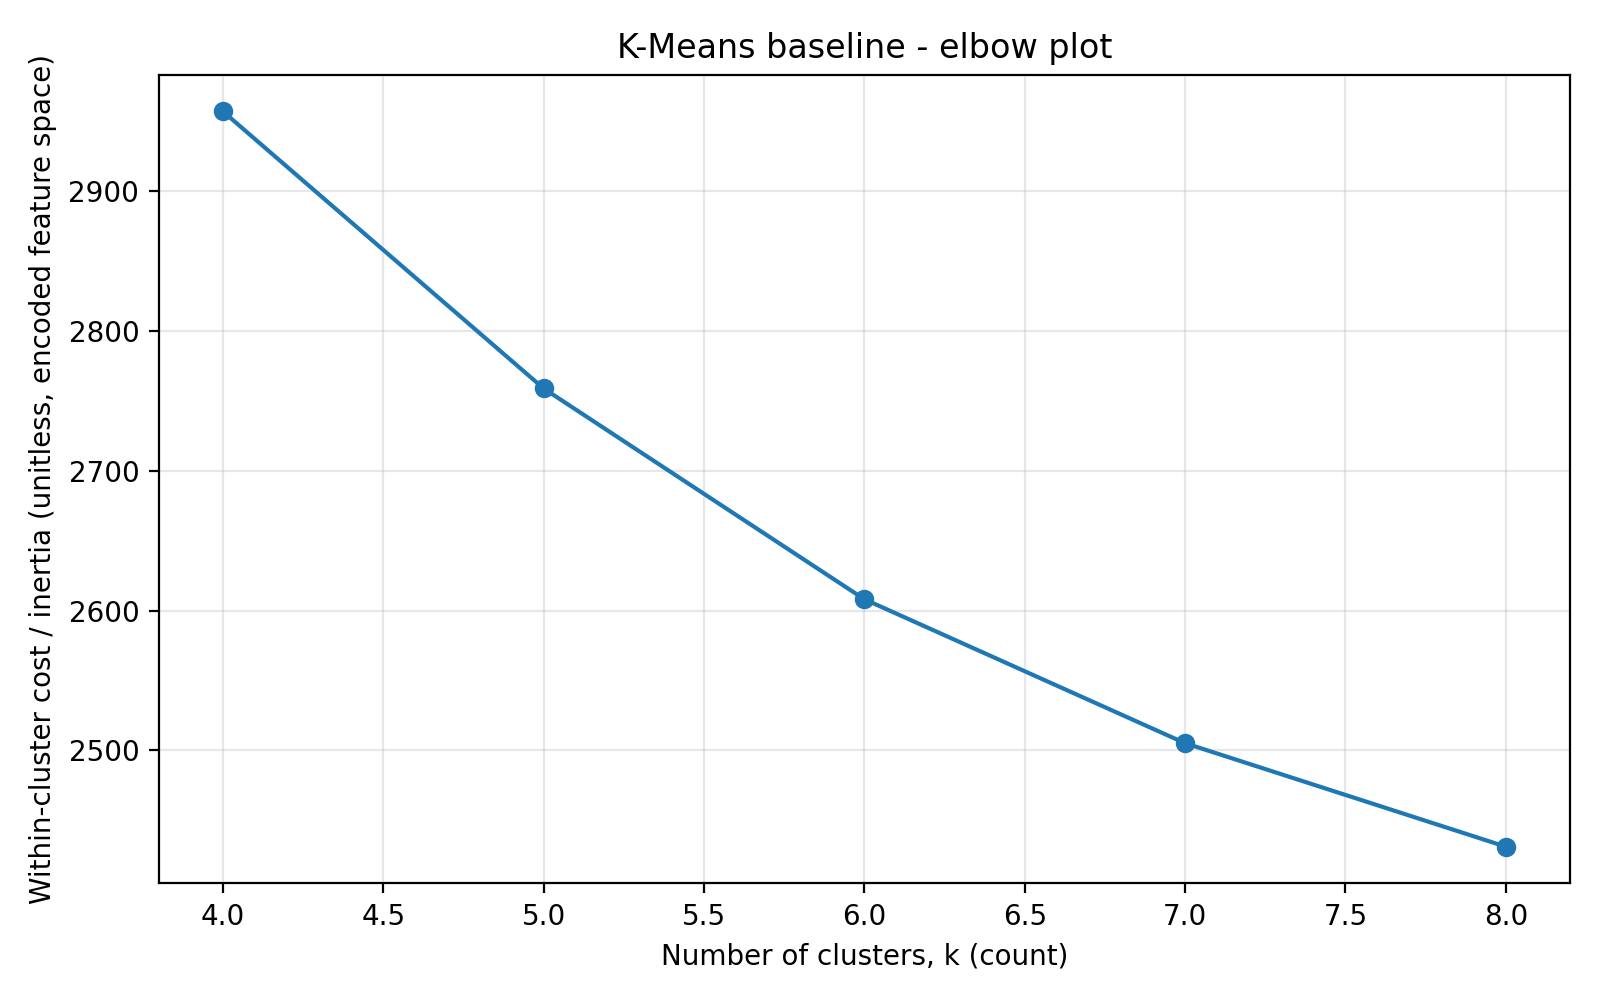

In [53]:
out_path = os.path.join(OUTPUT_DIR, "kmeans_elbow.png")
save_kmeans_elbow_plot(benchmark_df, out_path)
display(Image(filename=out_path))

## 21) Plot: benchmark silhouette comparison

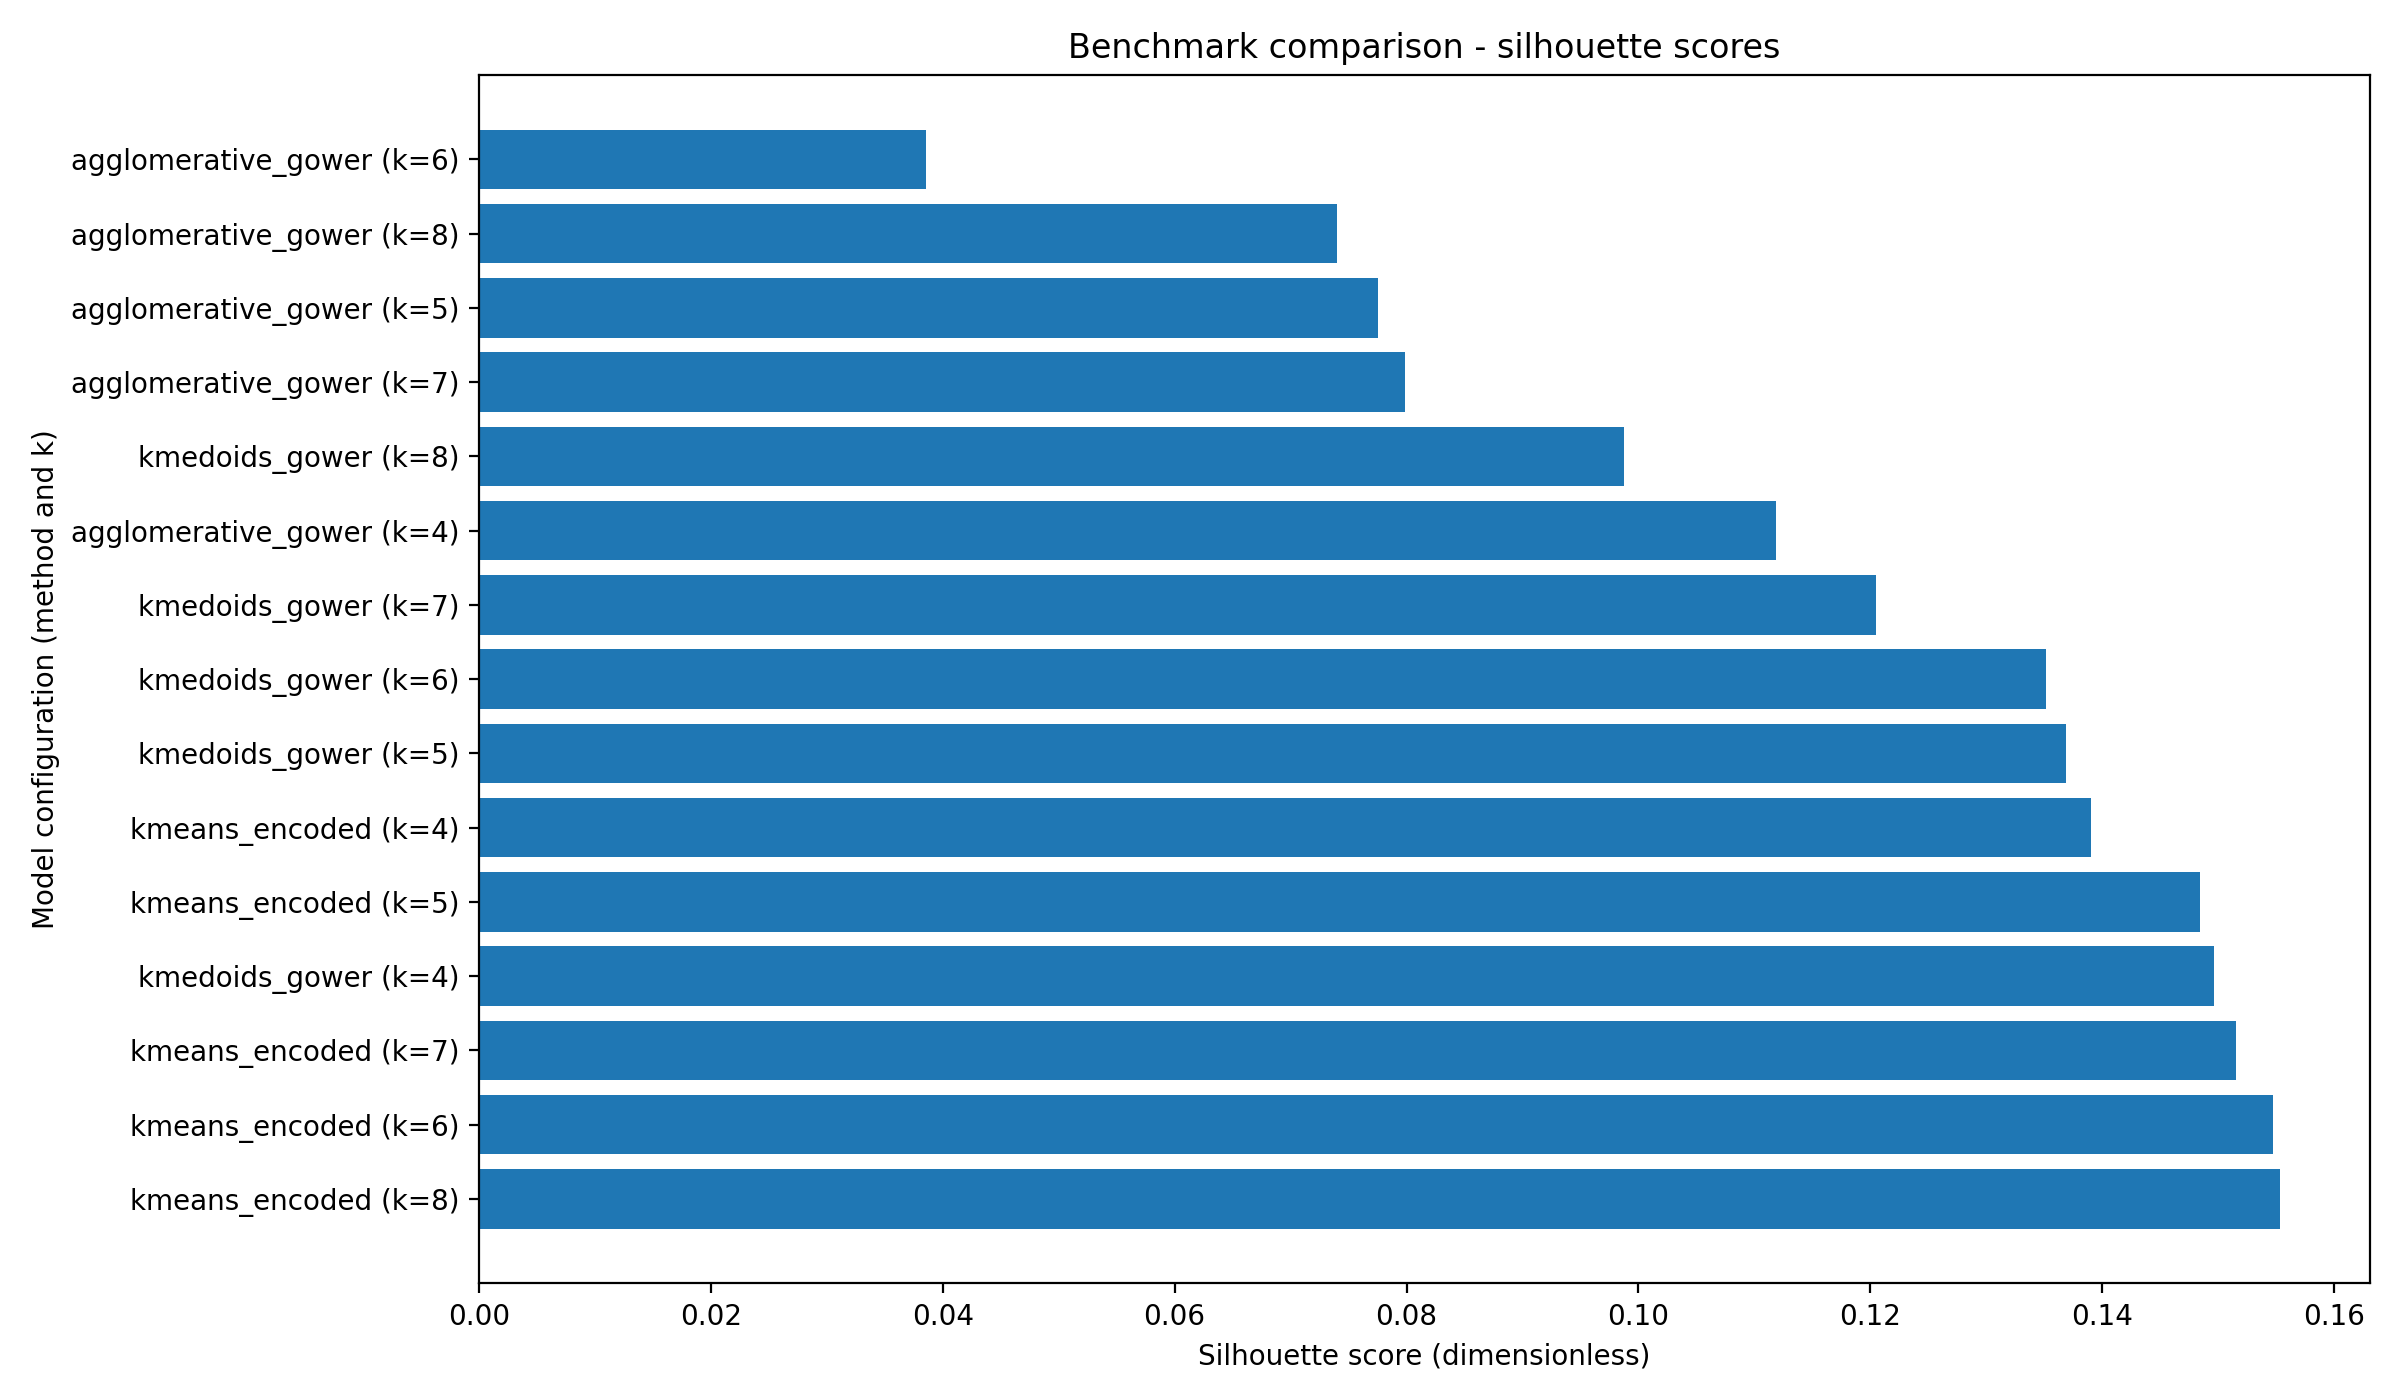

In [54]:
out_path = os.path.join(OUTPUT_DIR, "benchmark_silhouette.png")
save_benchmark_silhouette_plot(benchmark_df, out_path)
display(Image(filename=out_path))

## 22) Plot: DBSCAN KNN curve

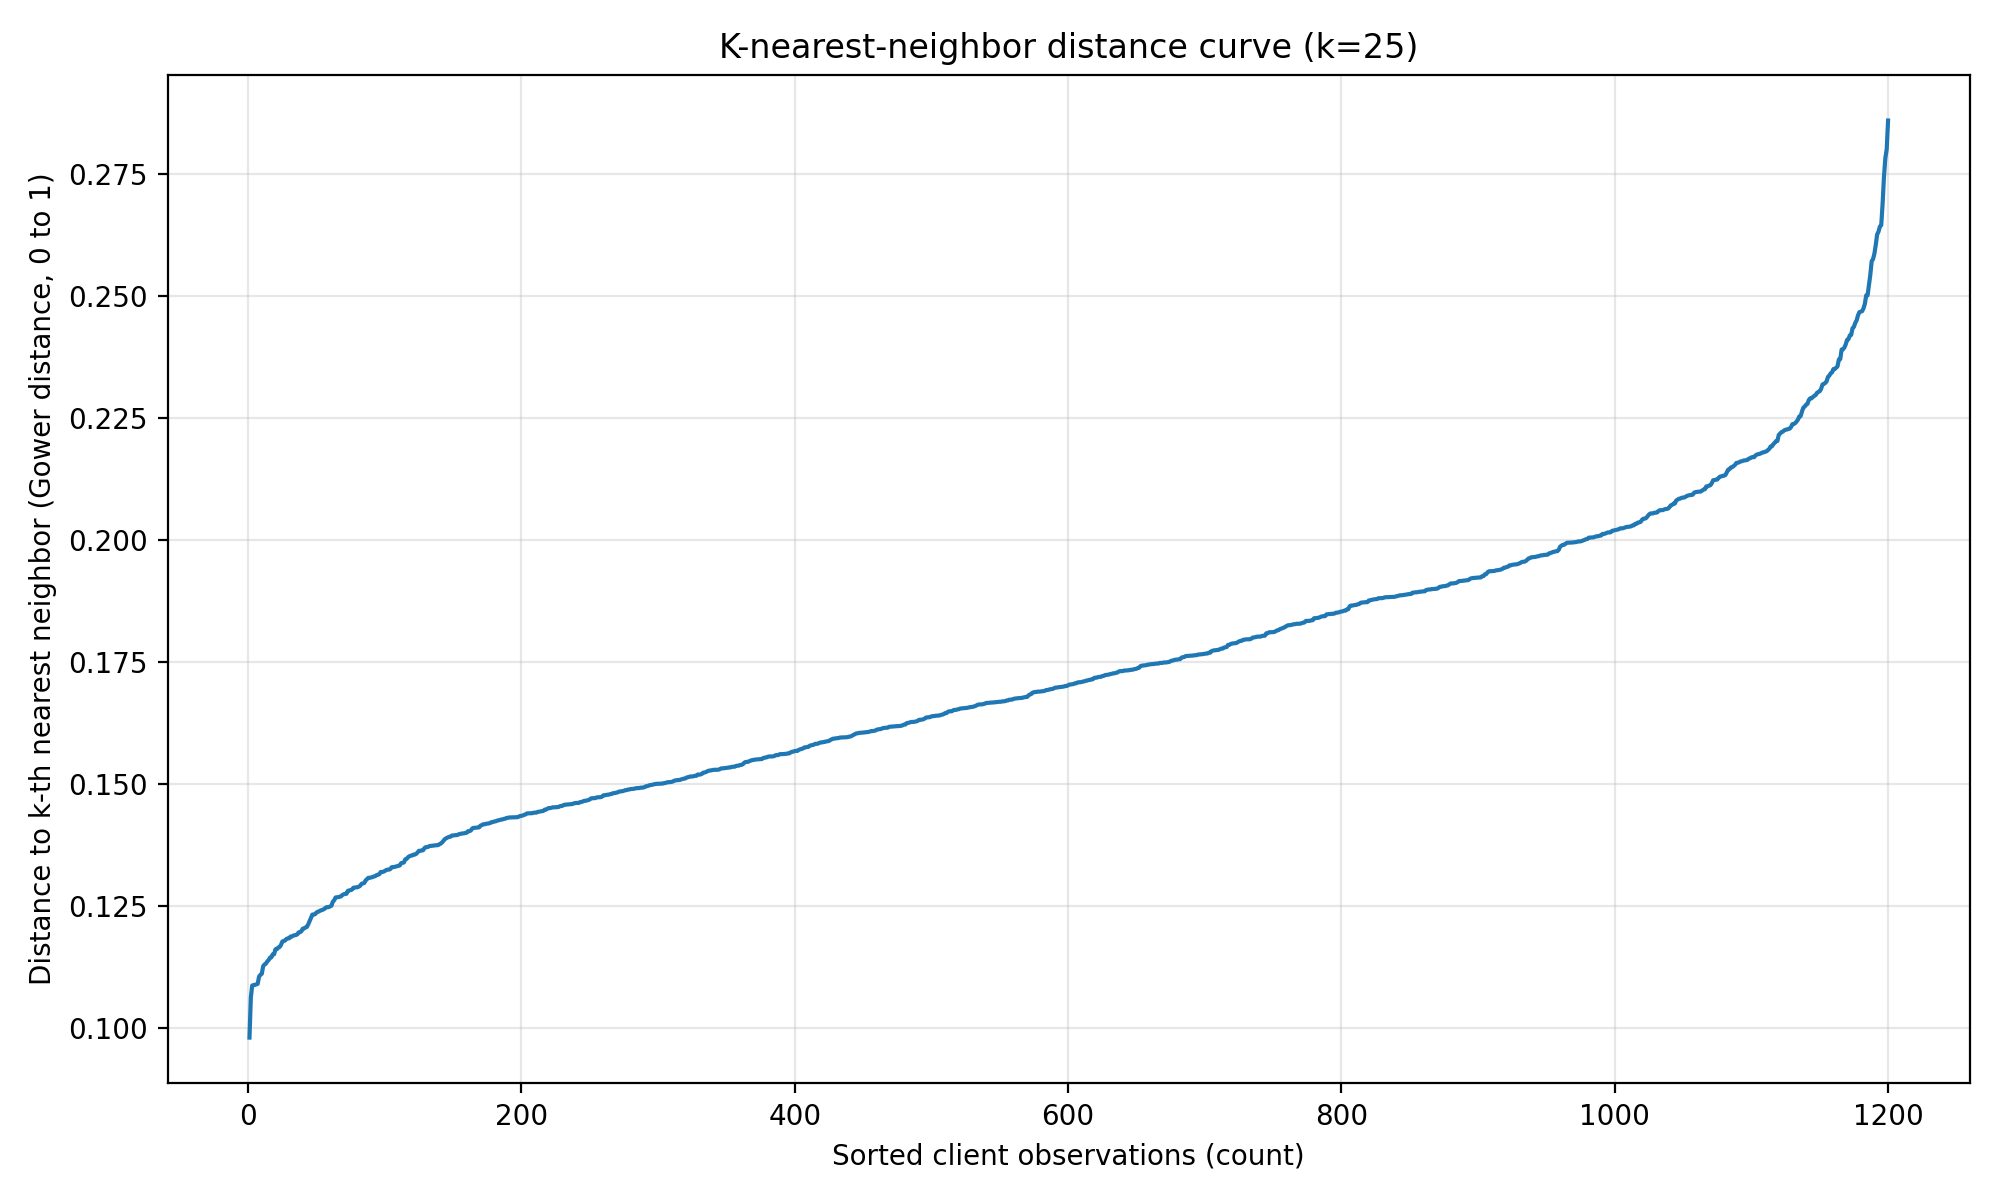

In [55]:
out_path = os.path.join(OUTPUT_DIR, "dbscan_knn_curve.png")
save_dbscan_knn_plot(knn_curve_df, out_path)
display(Image(filename=out_path))

## 23) Plot: cluster sizes

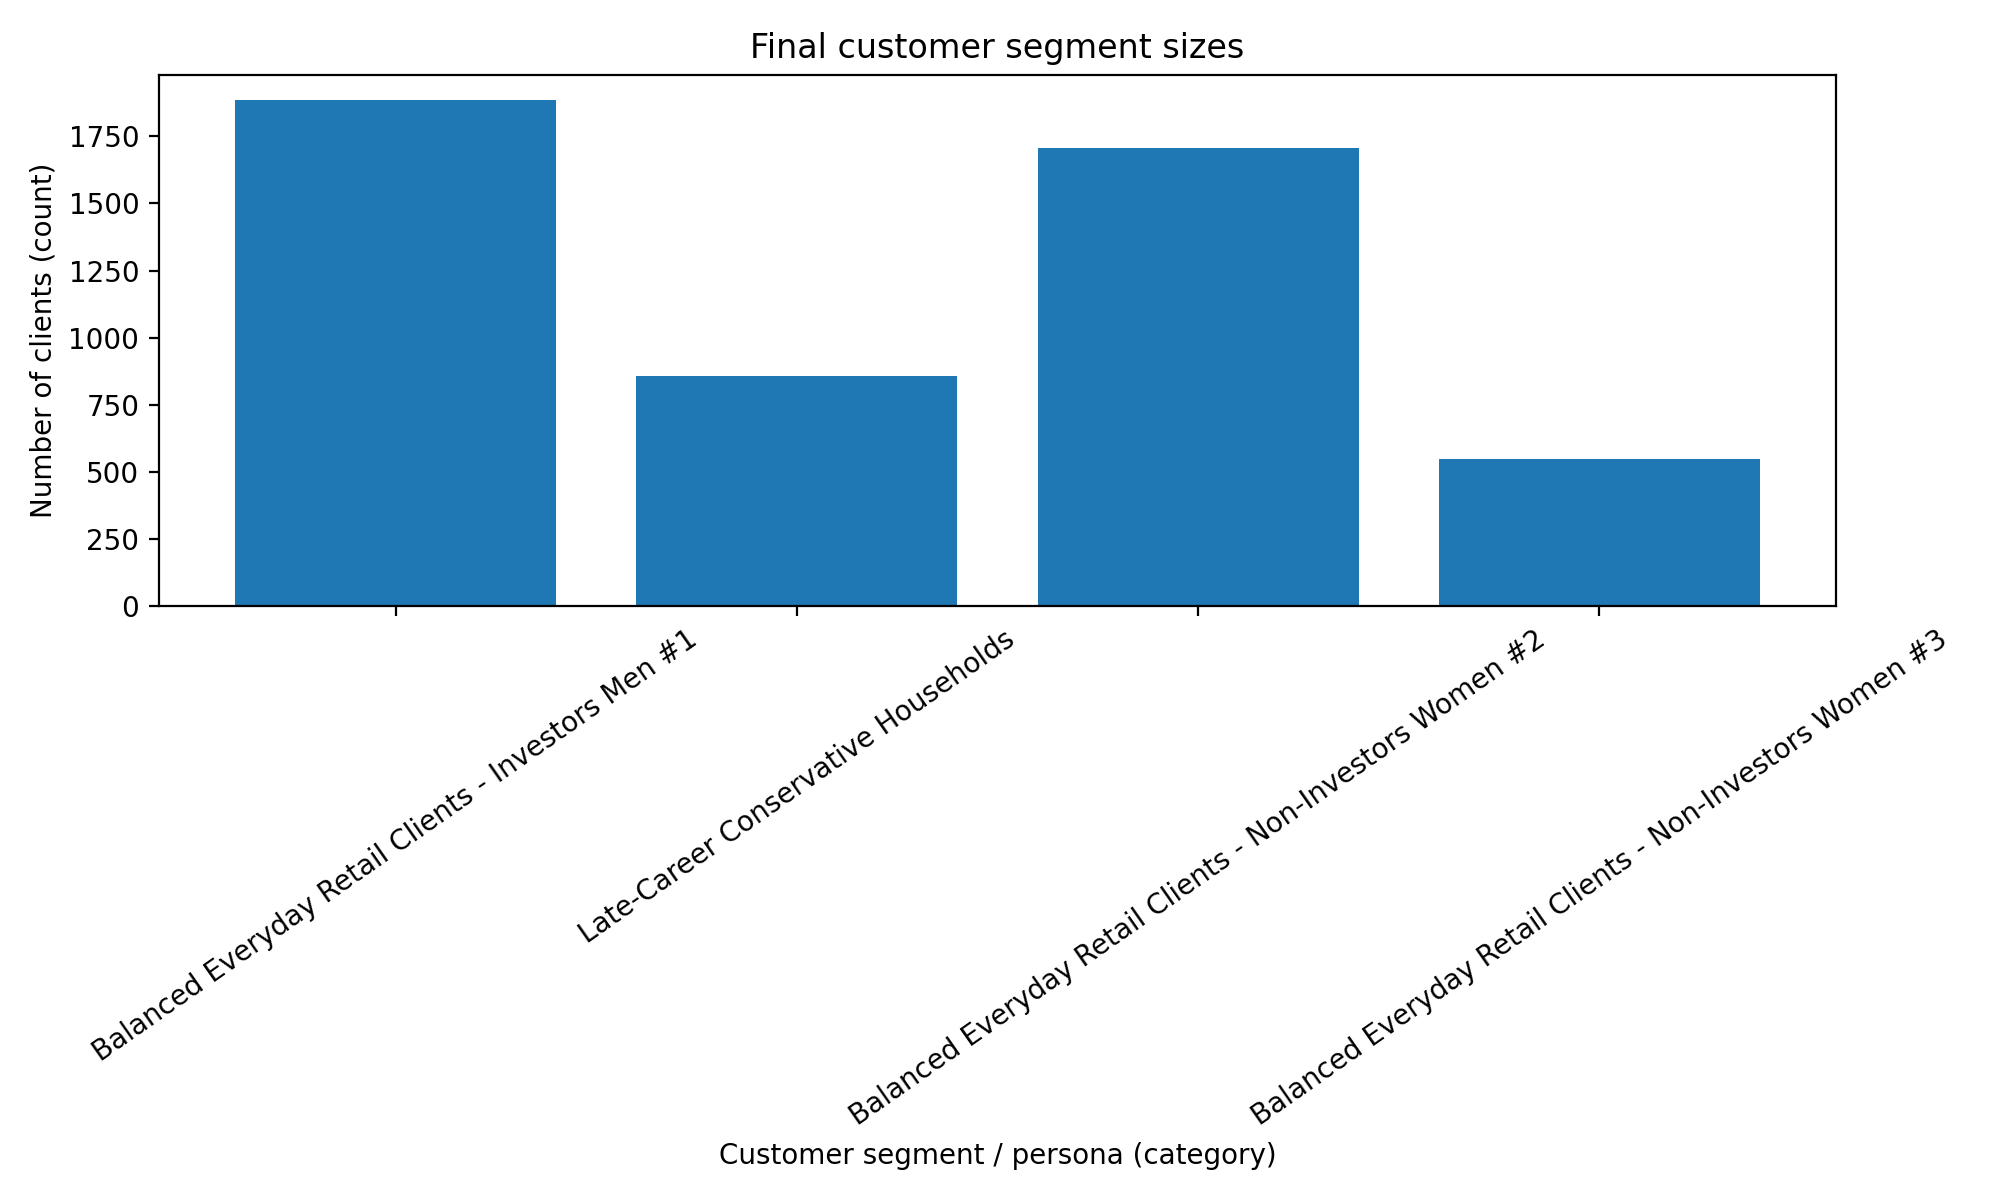

In [56]:
out_path = os.path.join(OUTPUT_DIR, "cluster_sizes.png")
save_cluster_size_plot(profiles, out_path)
display(Image(filename=out_path))

## 24) Plot: PCA scatter of final clusters

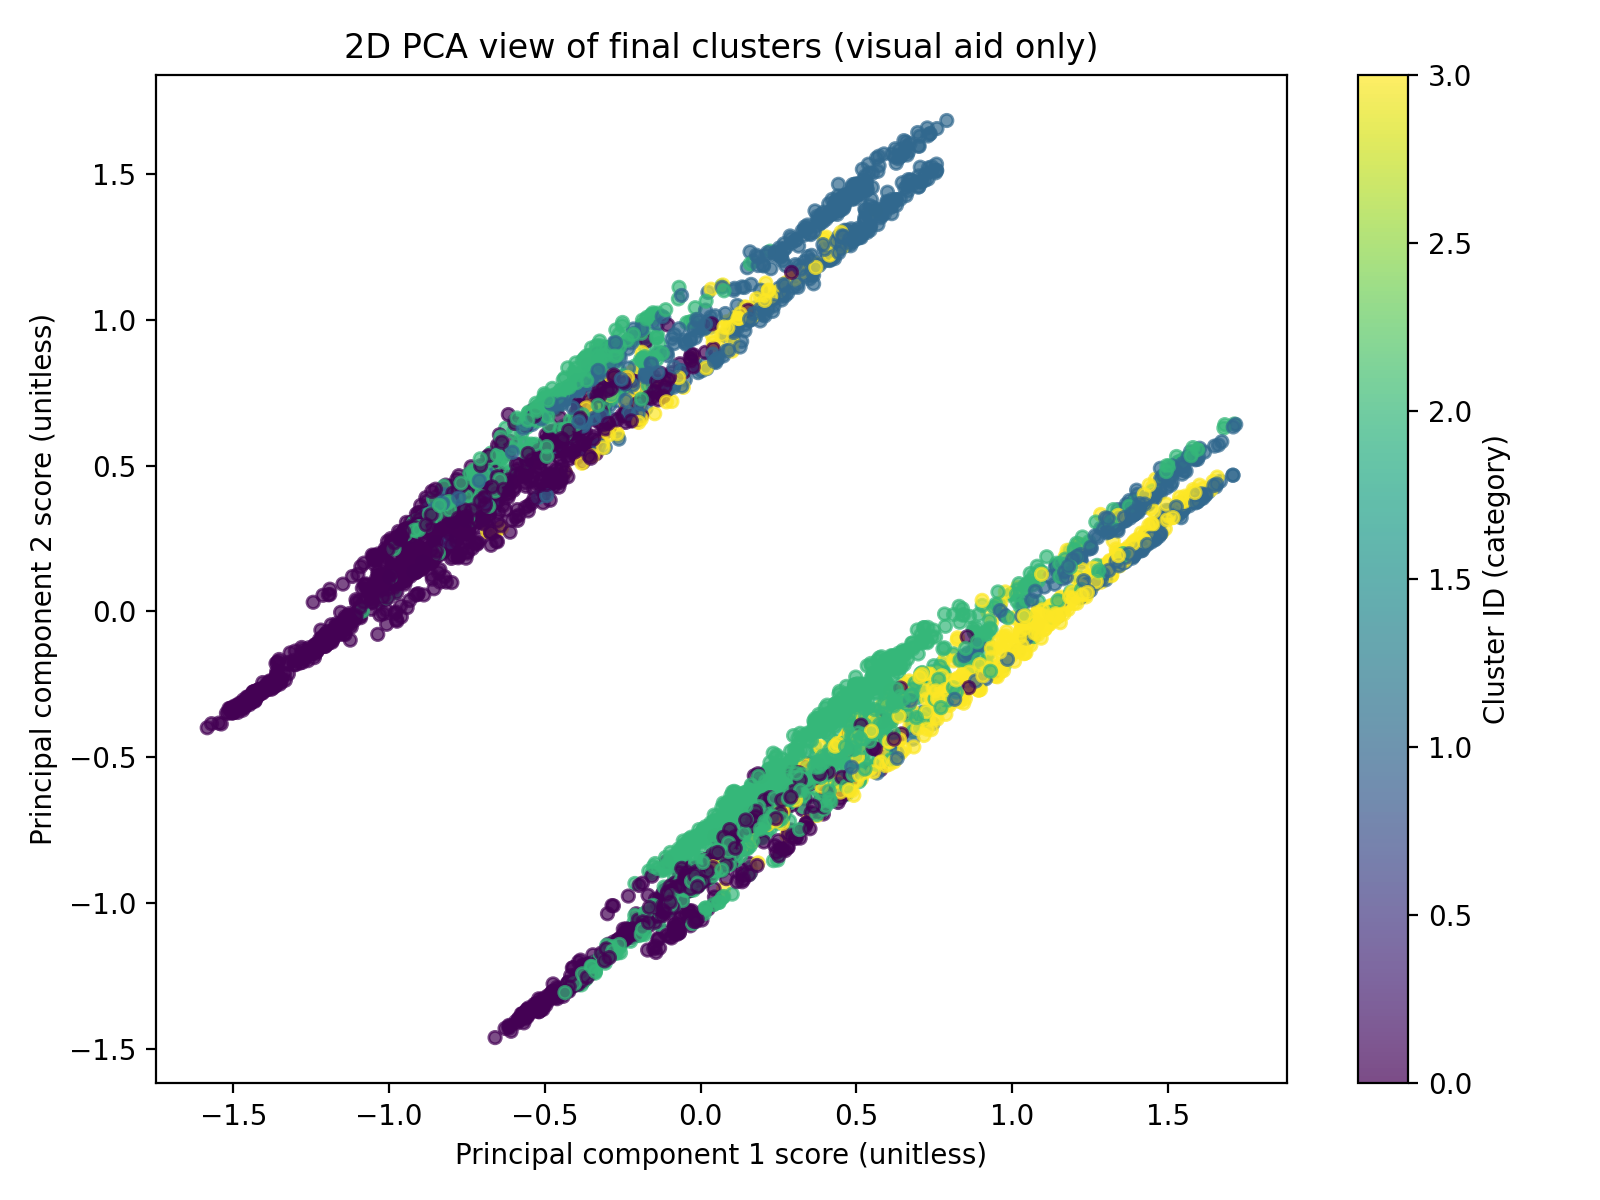

In [57]:
out_path = os.path.join(OUTPUT_DIR, "clusters_pca.png")
save_pca_scatter(segmented_df, numeric_cols, categorical_cols, out_path)
display(Image(filename=out_path))

## 25) Plot: profile heatmap

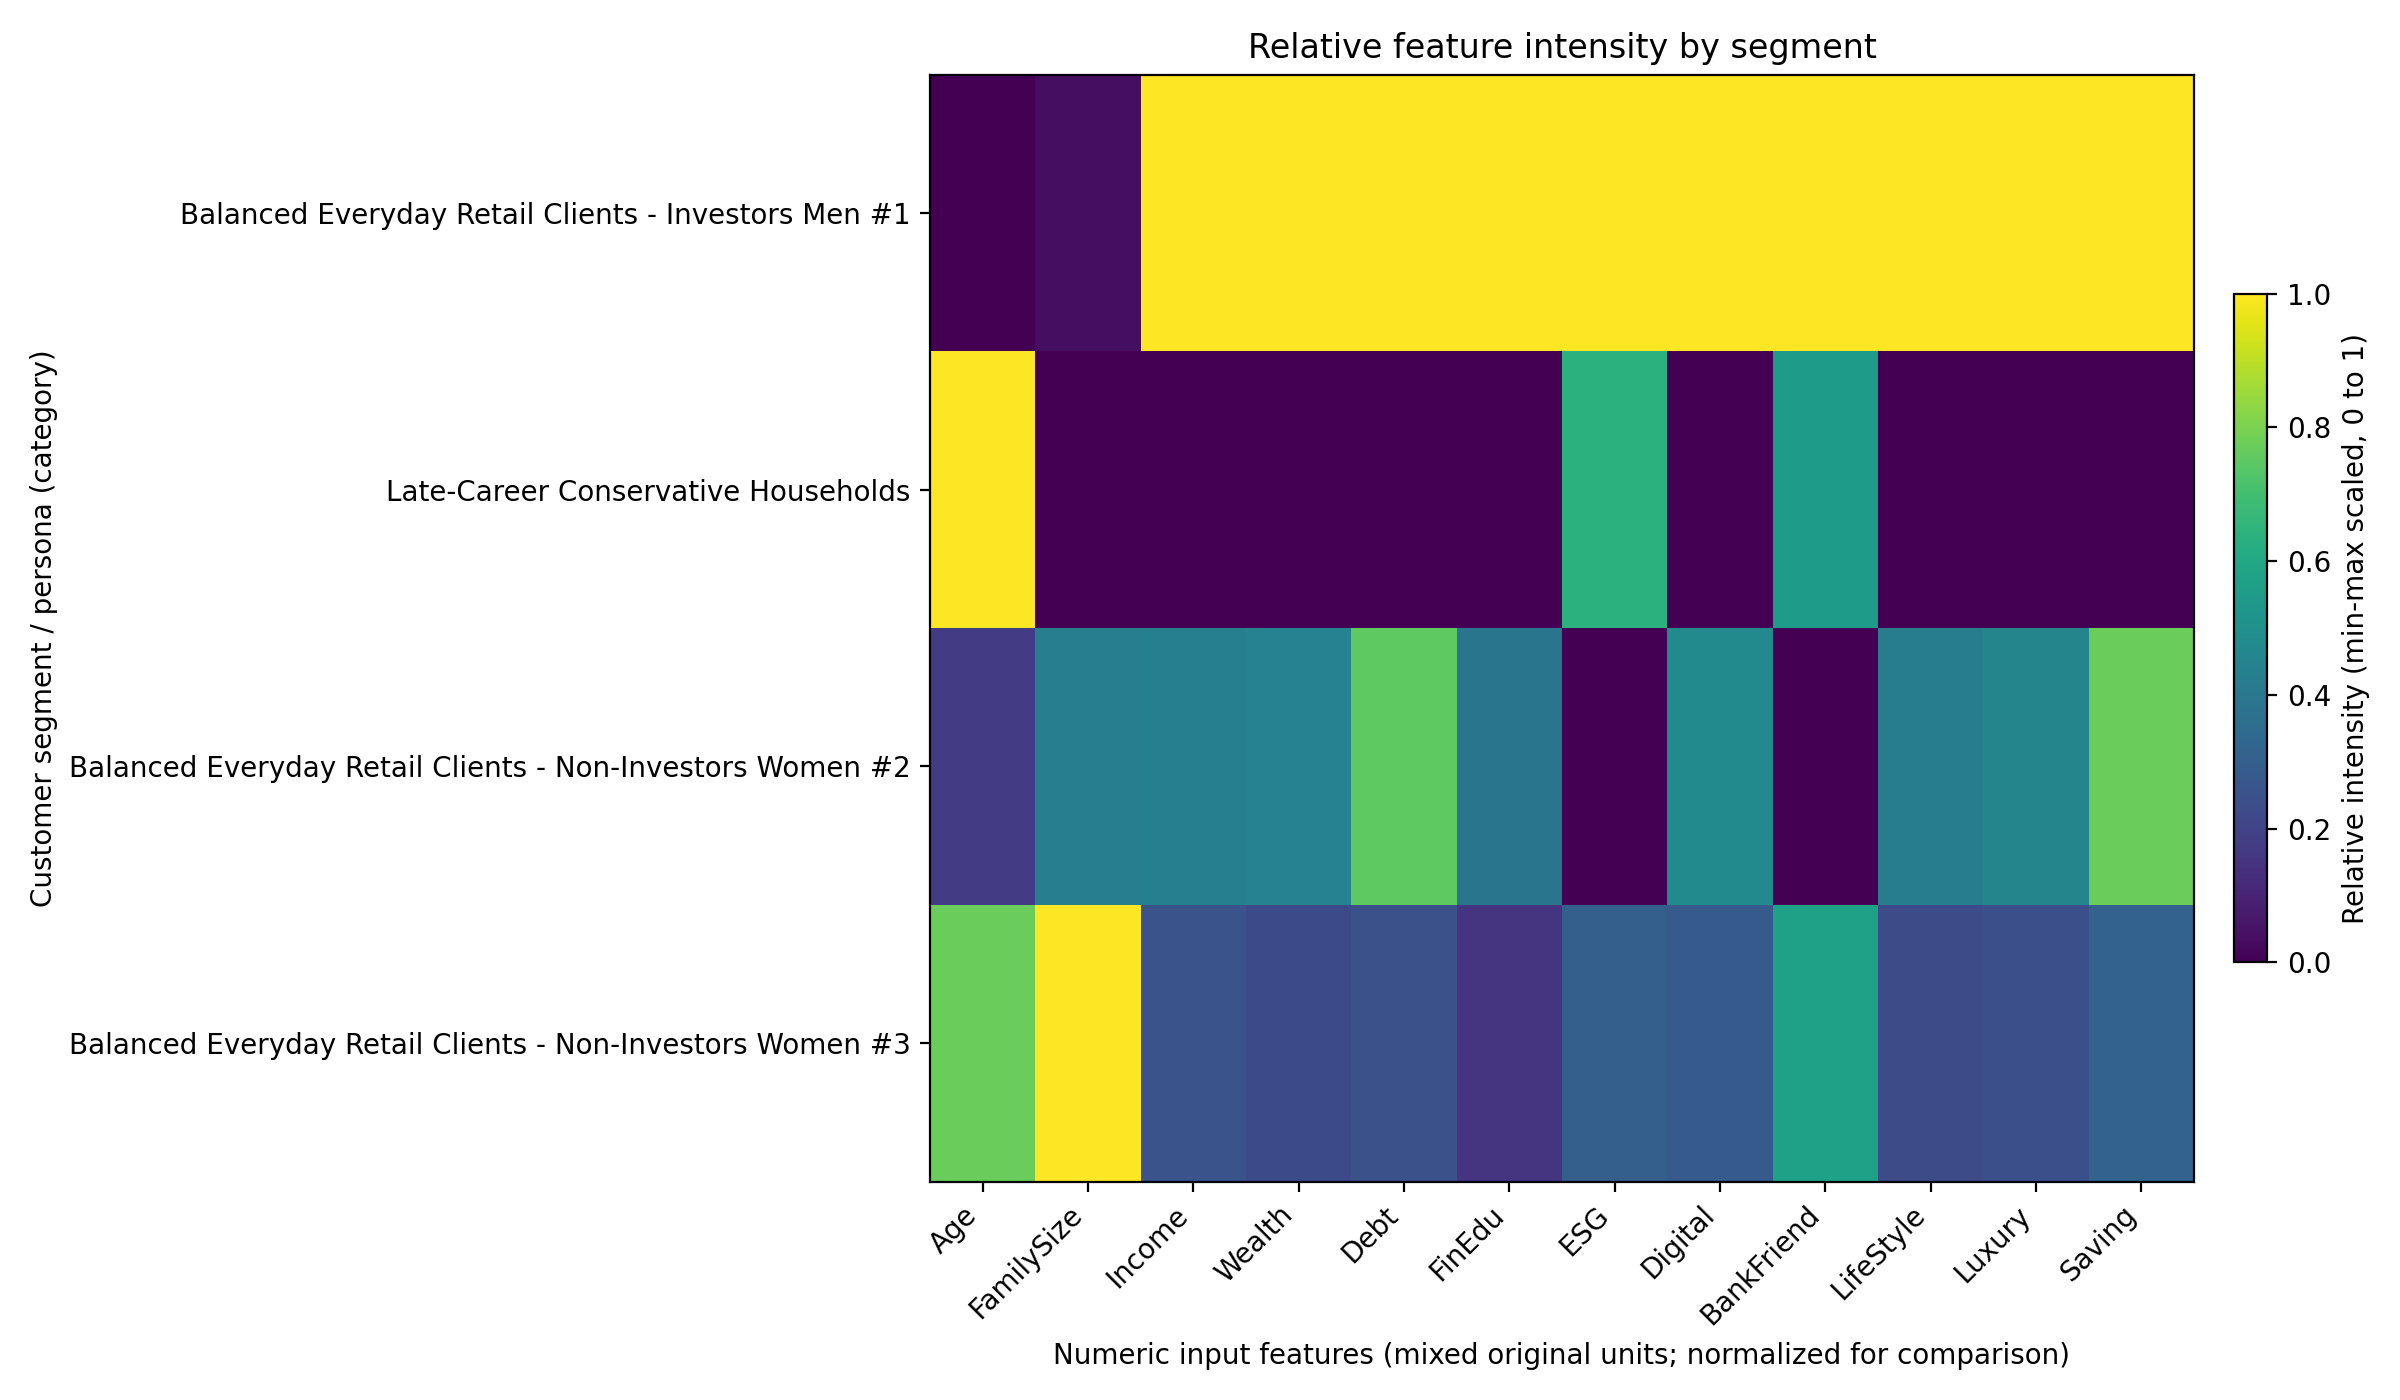

In [58]:
out_path = os.path.join(OUTPUT_DIR, "cluster_profile_heatmap.png")
save_profile_heatmap(profiles, numeric_cols, out_path)
display(Image(filename=out_path))

## 26) Plot: final silhouette sample

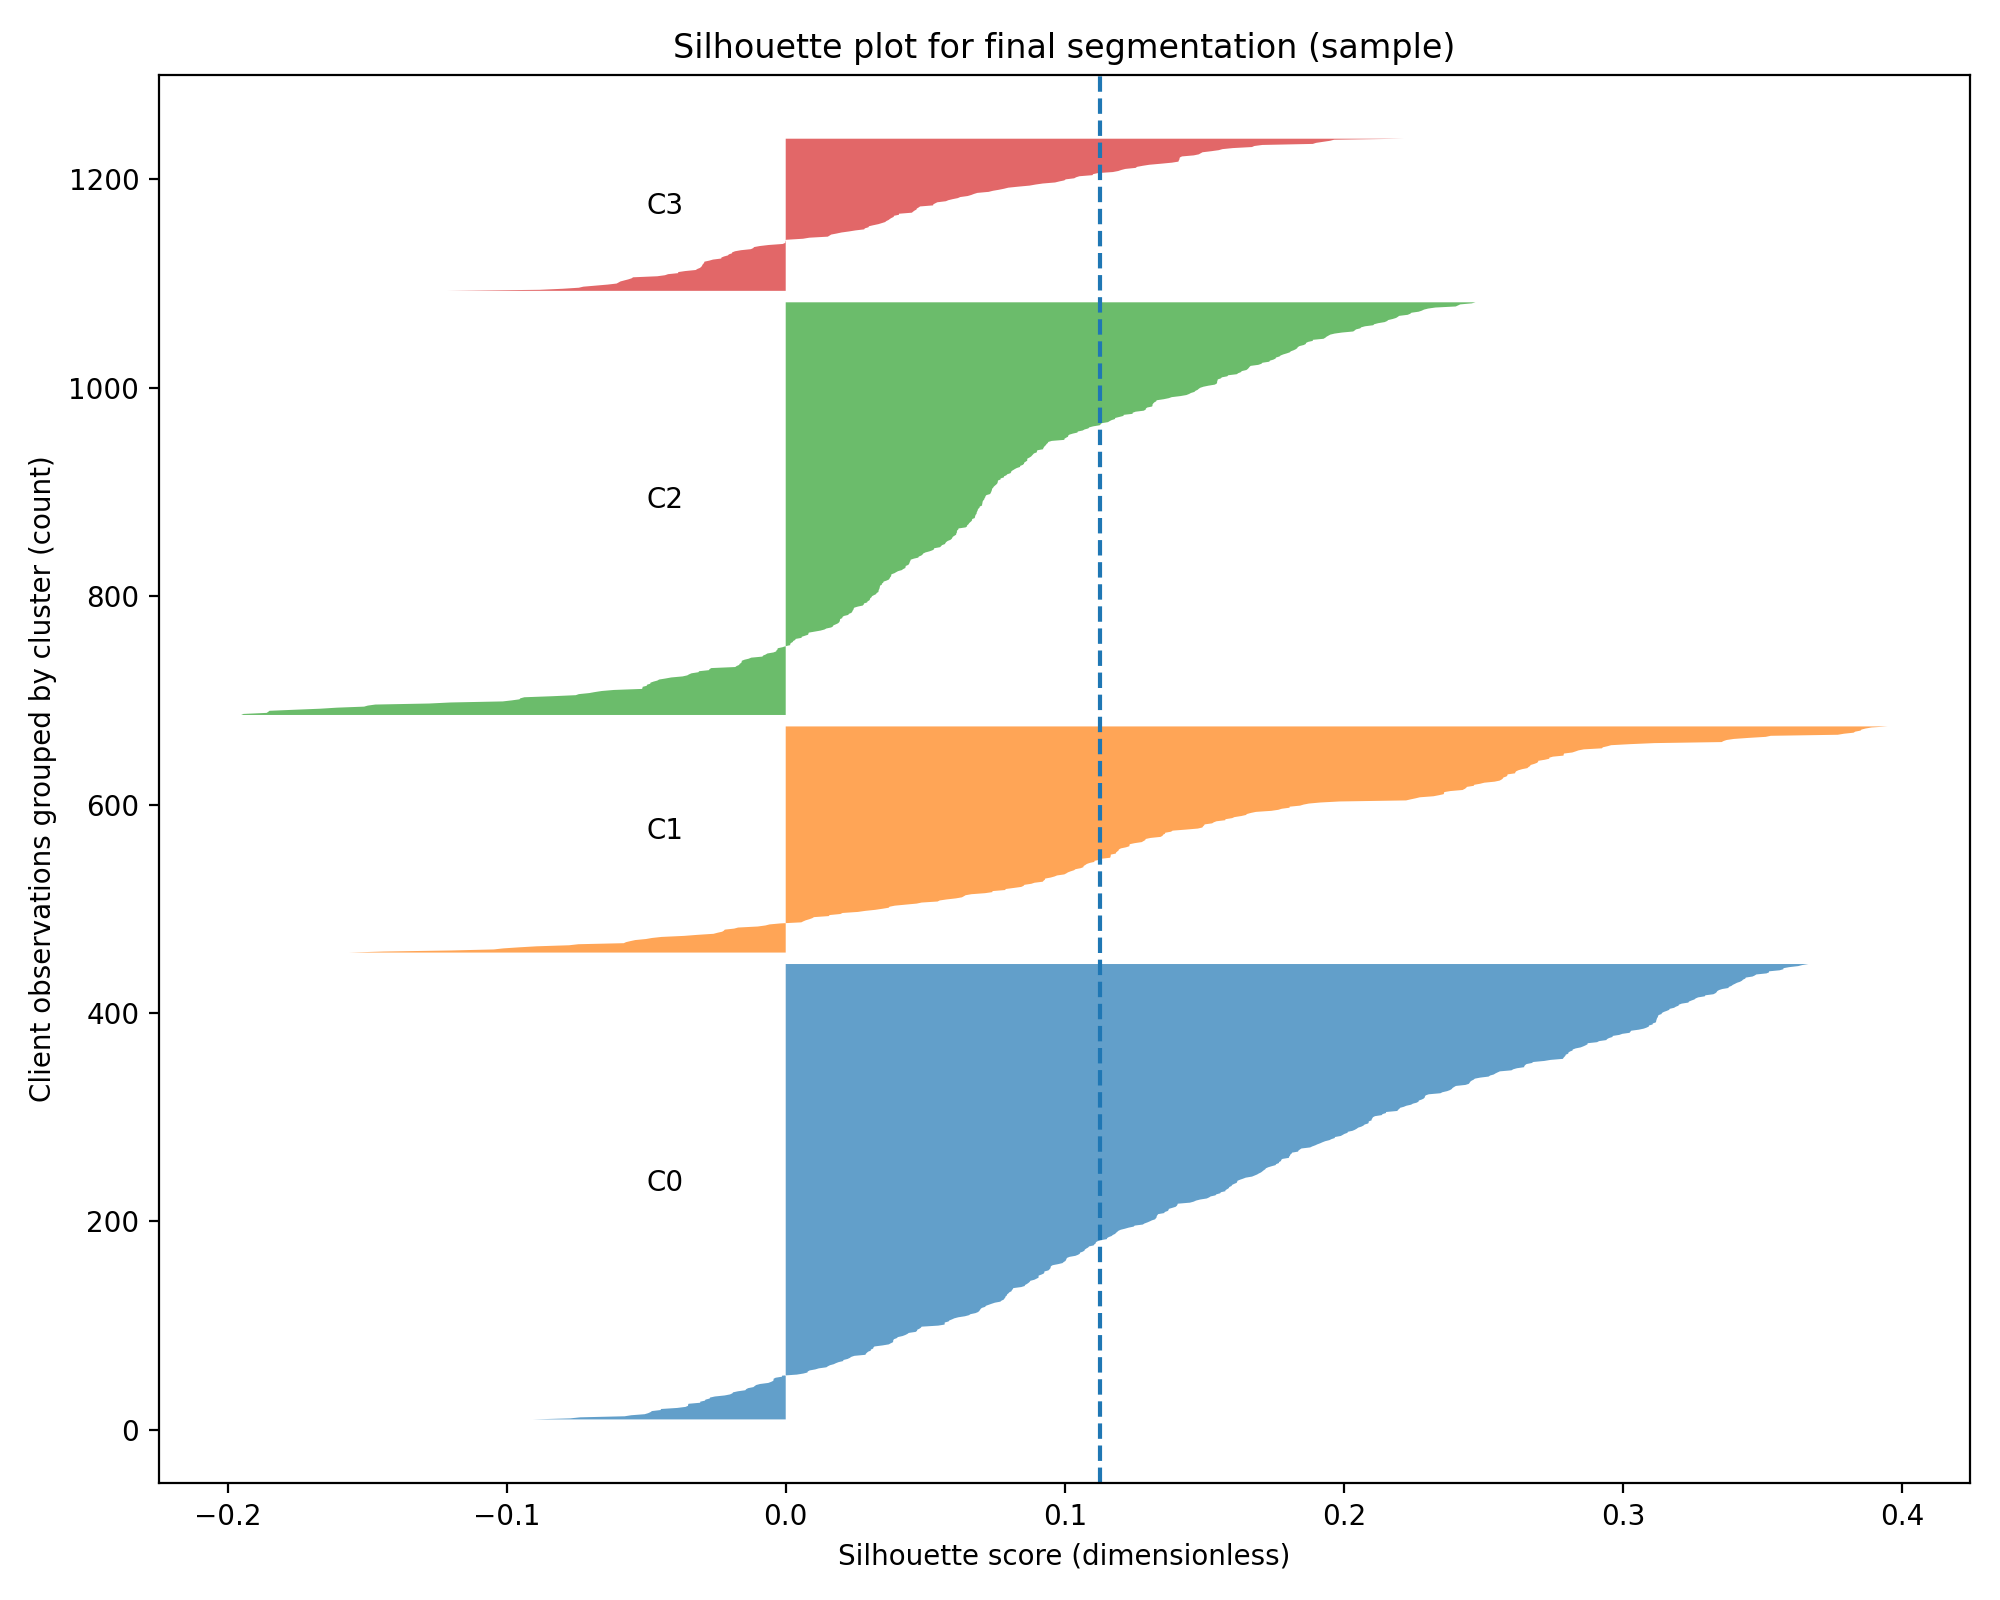

In [59]:
out_path = os.path.join(OUTPUT_DIR, "final_silhouette_sample.png")
save_final_silhouette_plot(D_sample, reference_labels_sample, out_path)
display(Image(filename=out_path))

## 27) Plot: stability across seeds

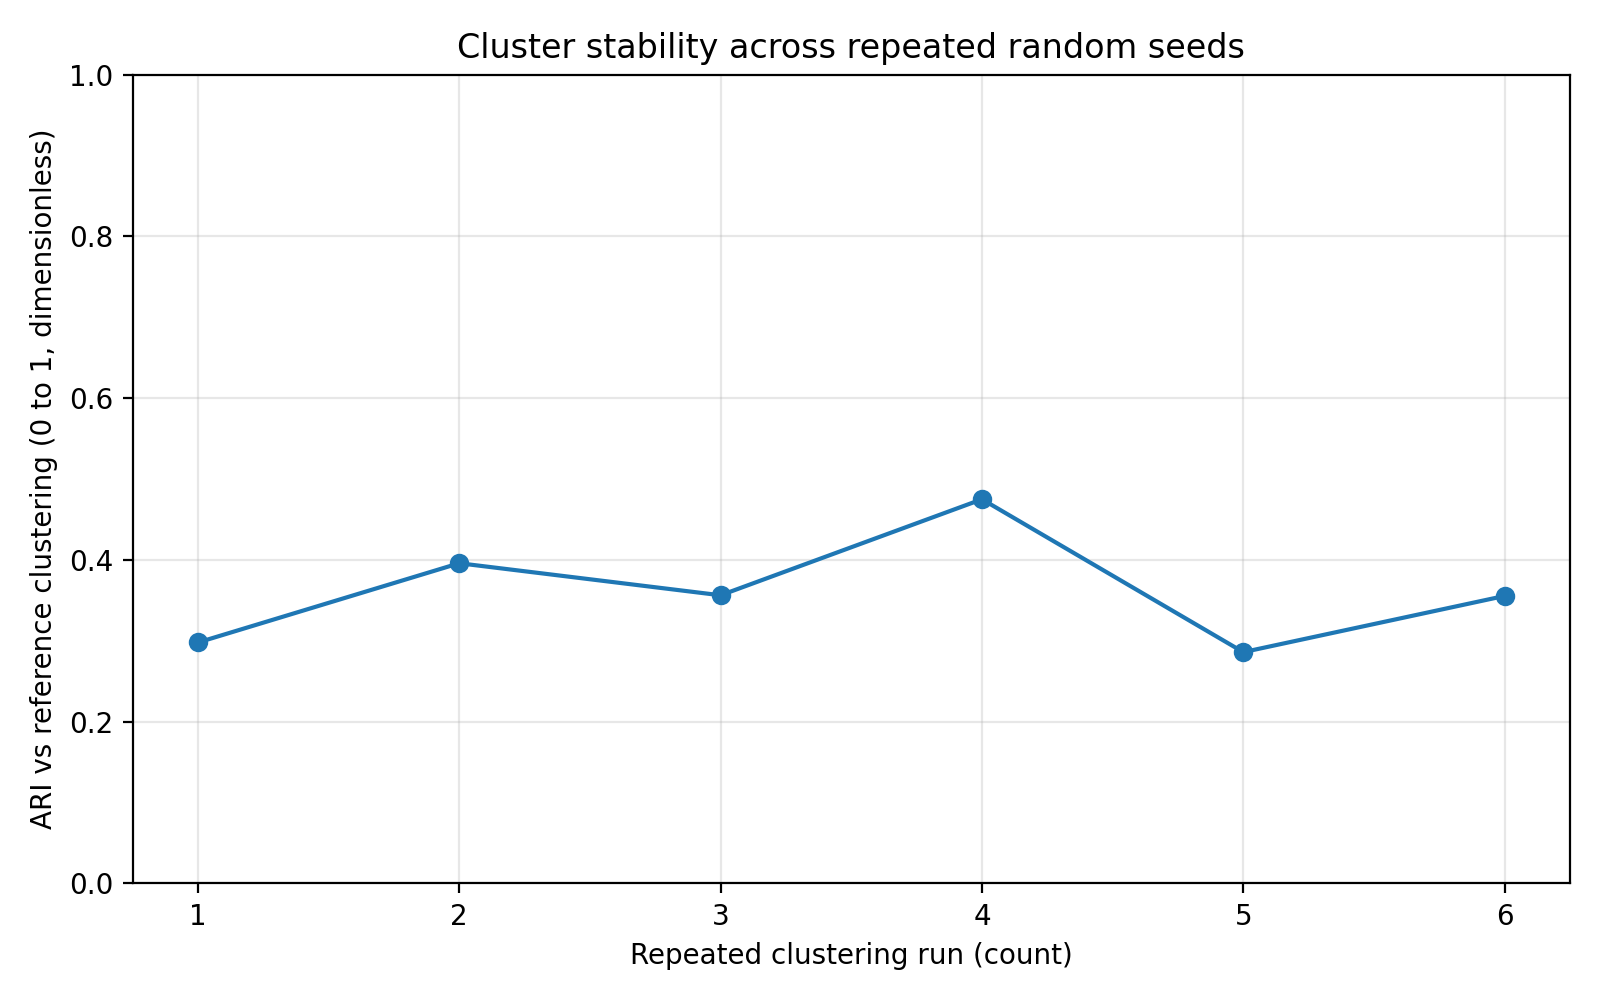

In [60]:
out_path = os.path.join(OUTPUT_DIR, "stability_plot.png")
save_stability_plot(stability_df, out_path)
display(Image(filename=out_path))

## 28) Plot: weight sensitivity

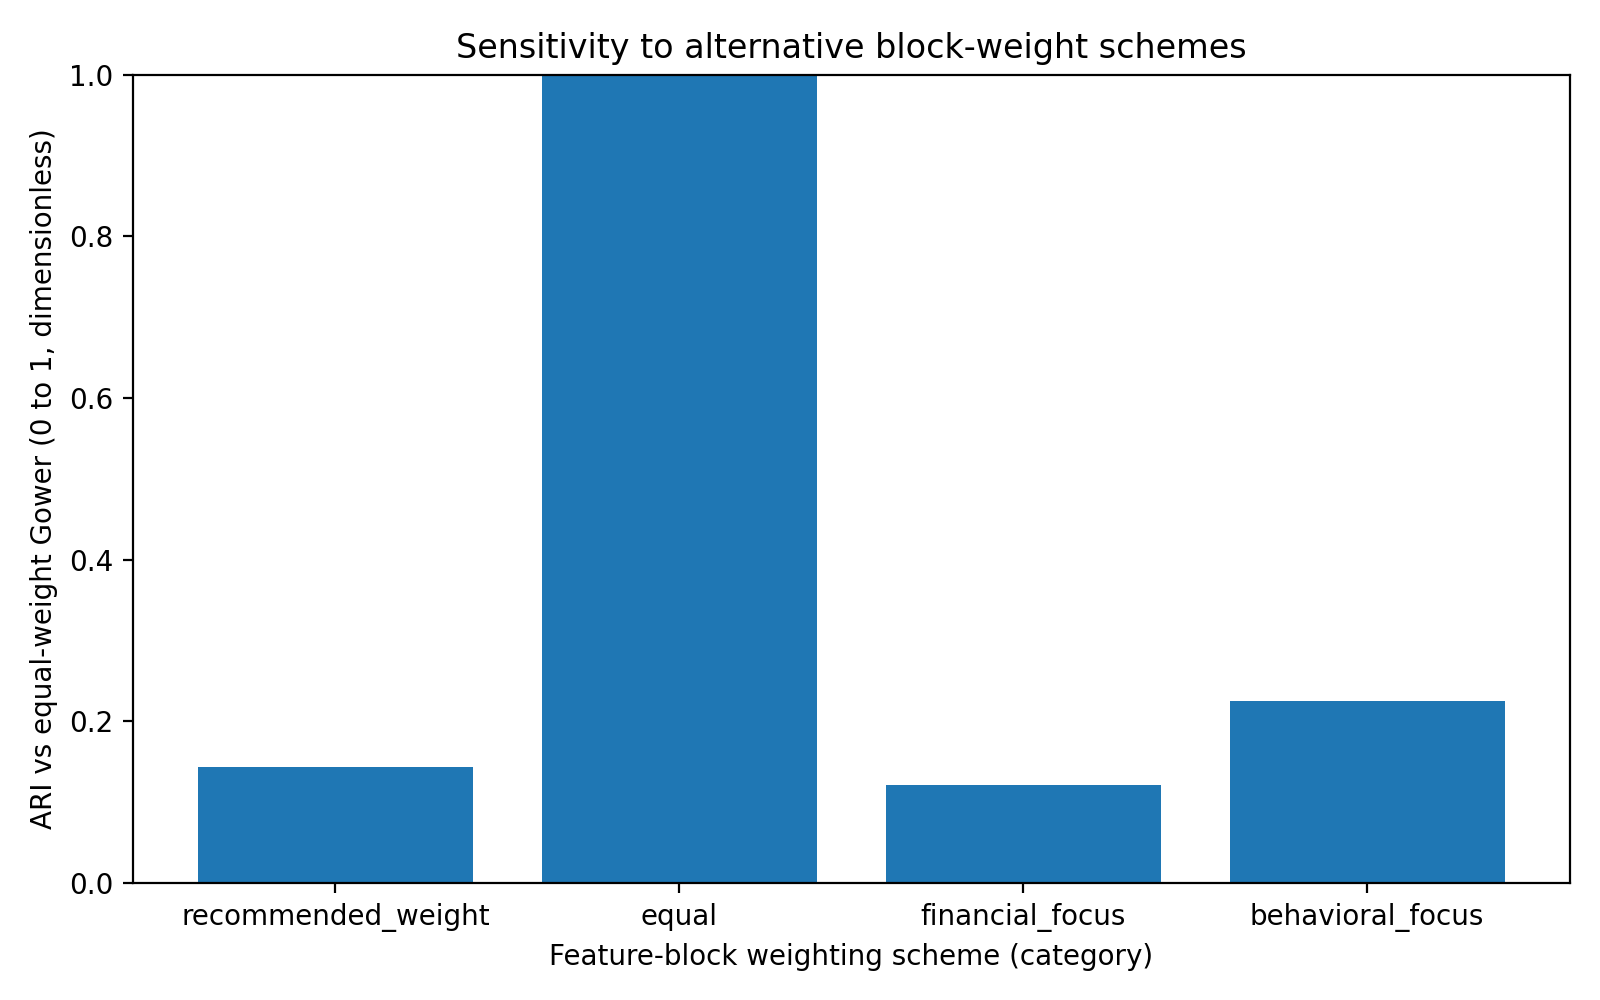

In [61]:
out_path = os.path.join(OUTPUT_DIR, "weight_sensitivity_plot.png")
save_sensitivity_plot(sensitivity_df, out_path)
display(Image(filename=out_path))

## 29) Quick summary

In [62]:
print("=" * 80)
print("UPGRADED CLIENT SEGMENTATION PIPELINE - SUMMARY")
print("=" * 80)
print("Final method: K-Medoids on equal-weight Gower distance")
print(f"Chosen number of segments: {chosen_k}")
print(f"Stability mean ARI: {stability_df['ari_vs_reference'].mean():.3f}")
print(f"Weighted sensitivity mean ARI: {sensitivity_df['ari_vs_equal_gower'].fillna(1.0).mean():.3f}")
print(f"Outputs saved to: {OUTPUT_DIR}")
for name in sorted(os.listdir(OUTPUT_DIR)):
    print(f" - {name}")

UPGRADED CLIENT SEGMENTATION PIPELINE - SUMMARY
Final method: K-Medoids on equal-weight Gower distance
Chosen number of segments: 4
Stability mean ARI: 0.361
Weighted sensitivity mean ARI: 0.372
Outputs saved to: C:\Users\Maxime\Documents\Milan\Fintech\BusinessCase1
 - .ipynb_checkpoints
 - AdditionalContentPoliMI.ipynb
 - BankClients_Metadata.xlsx
 - CODE.FINTECH.BC1.ipynb
 - CODE.FINTECH.BC1_repaired_after_metrics.ipynb
 - Dataset1_BankClients.xlsx
 - GMM
 - GMM_BC1.ipynb
 - GMM_BC1_bis.ipynb
 - HDBSCAN
 - HDBSCAN_BC1.ipynb
 - Lab1_optimization sol.ipynb
 - Lab1_optimization.ipynb
 - PPT.FINTECH.BC1.pptx
 - SegmentingClientsPoliMI.ipynb
 - Zenti_Business_Case_1.pdf
 - audit_report.txt
 - bayesian-learning.ipynb
 - benchmark_model_comparison.csv
 - benchmark_silhouette.png
 - cleaning_pipeline.py
 - cluster_medoids.csv
 - cluster_profile_heatmap.png
 - cluster_profiles.csv
 - cluster_sizes.png
 - cluster_stability.csv
 - clusters_pca.png
 - dbscan_knn_curve.csv
 - dbscan_knn_curve.png